In [ ]:
%load_ext autoreload
%autoreload 2

##### 0.1 不仅计算平均值,将每个查询的估计结果保存为WO.json文件

In [ ]:
import os
import json
import sys
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)

from pythonProject.src.Structure_first.proxy_sample import ProxyStratifiedSampler
from pythonProject.src.Structure_first.compute_truth import GroundTruthManager

def _worker_process_single_file(
    agg_file: str,
    aggregated_dir: str,
    all_T_true_results: dict,
    config: dict
):
    """
    [子进程工作函数] 处理单个文件，运行 FastestO 算法 (WO 基线) 并返回指标。
    """
    if agg_file.startswith("aggregated_list_"):
        base = agg_file.replace("aggregated_list_", "")
    elif agg_file.startswith("aggregated_wide_"):
        base = agg_file.replace("aggregated_wide_", "")
    else:
        base = agg_file
    query_basename = base.replace(".csv", "") + ".graph"

    T_true = all_T_true_results.get(query_basename)
    if T_true is None:
        return None

    filepath = os.path.join(aggregated_dir, agg_file)

    try:
        # WO 内部只计算 sum(estimateW * oracle), 由于 estimateW 在生成时
        # 已经携带了 Upvotes（由Fastest输出），所以此处只需要对齐 T_true 即可正确计算 sum 的误差。
        sampler = ProxyStratifiedSampler(
            csv_path=filepath,
            is_multi_predicate=True,
            post_proxy=config["post_proxy"],
            comment_proxy=config["comment_proxy"],
            post_oracle=config["post_oracle"],
            comment_oracle=config["comment_oracle"],
            T_true=T_true
        )
        
        if sampler.posts.empty:
            return None

        # 运行基线 (Graph Only 意味着只经过 Fastest 图信息直接估算，对应你文章中的 WO)
        res = sampler.run_baseline_graph_only()
        
        return {
            "query_name": query_basename,
            "T_true": float(T_true),
            "T_hat": float(res.get("T_hat", 0.0)),
            "abs_error_rate": float(res["Qerror"]), 
            "n_post": res.get("n_post", 0),
            "n_comment": res.get("n_comment", 0),
            "Total_Cost": res.get("n_post", 0) + res.get("n_comment", 0)
        }
    except Exception as e:
        return None


def evaluate_fastest_o_multi_predicate_dataset_fast(
    dataset_name: str,
    parent_dataset: str = "parler_data",  # 【新增】支持多数据集
    table1: str = "post",                 # 【新增】表1名字
    table2: str = "comment",              # 【新增】表2名字
    agg_mode: str = "count",   # 【新增】控制实验类型
    sum_on: str = "post",      # 【新增】sum所在的实体 
    sum_col: str = "upvotes",  # 【新增】sum列 
    post_proxy_col: str = "ML1_proxy4b_probability",
    comment_proxy_col: str = "ML2_proxy1_probability",
    post_oracle_col: str = "ML1_oracle2_probability",
    comment_oracle_col: str = "ML2_oracle2_probability",
    max_workers: int = None
):
    """
    [多进程加速版] 对指定数据集下的所有查询运行 [FastestO (WO)]。
    """
    print(f"\n{'='*10} Evaluation: FastestO (Graph Only - {agg_mode.upper()}) {'='*10}")
    
    # 1. 处理 Ground Truth 读取
    gt_manager = GroundTruthManager(
        dataset_name=dataset_name,
        post_oracle_col=post_oracle_col,
        comment_oracle_col=comment_oracle_col,
        parent_dataset=parent_dataset,
        table1=table1,
        table2=table2
    )
    
    # 【修复】：主动拼装你在前面代码中保存的真实 JSON 文件路径读入结果，防止错位
    base, ext = os.path.splitext(gt_manager.cache_path)
    if agg_mode == "sum":
        safe_sum_col = str(sum_col).replace("/", "_").replace(":", "_")
        t_true_path = f"{base}_sum.json"
    else:
        # count 尝试读有 count 后缀的，读不到退回默认
        t_true_path = f"{base}_count{ext}"
        if not os.path.exists(t_true_path):
            t_true_path = gt_manager.cache_path

    if os.path.exists(t_true_path):
        print(f"读入 T_true 数据集: {t_true_path}")
        with open(t_true_path, 'r') as f:
            all_T_true_results = json.load(f)
    else:
        print(f"[Error] 未能找到真值文件: {t_true_path}")
        return

    # 2. 准备文件路径
    base_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}"
    aggregated_dir = os.path.join(base_path, "results", "aggregated_results")
    
    if not os.path.exists(aggregated_dir):
        print(f"[Error] 目录不存在: {aggregated_dir}")
        return

    agg_files = sorted([f for f in os.listdir(aggregated_dir) if f.endswith(".csv")])
    
    config = {
        "post_proxy": post_proxy_col, "comment_proxy": comment_proxy_col,
        "post_oracle": post_oracle_col, "comment_oracle": comment_oracle_col
    }

    # 3. 多进程执行
    metrics = {"Qerror": [], "Oracle_Cost_Post": [], "Oracle_Cost_Comment": [], "Total_Cost": []}
    detailed_results_list = []

    if max_workers is None:
        max_workers = max(1, os.cpu_count() - 2)

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_worker_process_single_file, f, aggregated_dir, all_T_true_results, config) for f in agg_files]
        
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"Processing {agg_mode.upper()} Queries"):
            result = future.result()
            if result:
                detailed_results_list.append(result)
                metrics["Qerror"].append(result["abs_error_rate"])
                metrics["Oracle_Cost_Post"].append(result["n_post"])
                metrics["Oracle_Cost_Comment"].append(result["n_comment"])
                metrics["Total_Cost"].append(result["Total_Cost"])

    # 4. 排序与保存结果
    if not metrics["Qerror"]: 
        print("[Warn] 无有效结果。")
        return

    detailed_results_list.sort(key=lambda x: x["abs_error_rate"], reverse=True)

    output_dir = os.path.join(base_path, "results", "efficiency")
    os.makedirs(output_dir, exist_ok=True)
    
    # 【保护】：将结果保存在对应的后缀中以区分 sum 和 count 结果
    suffix = "_sum" if agg_mode == "sum" else "_count"
    
    output_json = os.path.join(output_dir, f"WO{suffix}.json")
    try:
        with open(output_json, 'w') as f:
            json.dump(detailed_results_list, f, indent=4)
        print(f"✅ 详细误差分析已保存至 (按误差降序): {output_json}")
    except Exception as e:
        print(f"❌ 保存 JSON 失败: {e}")

    avg_qerror = np.mean(metrics["Qerror"])
    output_csv = os.path.join(output_dir, f"WO_summary_{suffix}.csv")
    df_summary = pd.DataFrame([{
        "dataset_name": dataset_name, 
        "method": "WO", 
        "agg_mode": agg_mode,
        "num_queries": len(metrics["Qerror"]),
        "mean_are": avg_qerror, 
        "avg_total_cost": np.mean(metrics["Total_Cost"])
    }])
    df_summary.to_csv(output_csv, mode='a', header=not os.path.exists(output_csv), index=False)

    print(f"✅ 统计汇总已更新至: {output_csv}")
    print(f"Global Mean ARE ({agg_mode.upper()}): {avg_qerror:.6f}")

if __name__ == "__main__":
    # 调用即可执行 amazon_extend 数据集的 SUM 版本的 WO
    evaluate_fastest_o_multi_predicate_dataset_fast(
        dataset_name="amazon_extend",  
        parent_dataset="amazon_data",
        table1="product",
        table2="review",
        agg_mode="sum",
        sum_on="product",
        sum_col="price",
        post_proxy_col="ML3_proxy2_probability",
        comment_proxy_col="ML2_proxy1_probability",
        post_oracle_col="ML3_oracle2_probability",
        comment_oracle_col="ML2_oracle1_probability"
    )
    # evaluate_fastest_o_multi_predicate_dataset_fast(
    #     dataset_name="dataset_test",  
    #     parent_dataset = "parler_data",  # 【新增】支持多数据集
    #     table1 = "post",                 # 【新增】表1名字
    #     table2  = "comment",              # 【新增】表2名字
    #     agg_mode  = "sum",   # 【新增】控制实验类型
    #     sum_on  = "post",      # 【新增】sum所在的实体 
    #     sum_col  = "upvotes",  # 【新增】sum列 
    #     post_proxy_col = "ML1_proxy4b_probability",
    #     comment_proxy_col = "ML2_proxy1_probability",
    #     post_oracle_col = "ML1_oracle2_probability",
    #     comment_oracle_col = "ML2_oracle2_probability",
    #     max_workers = None
    # )

#### 3.基线方法 FastestO

##### 4.10 最终误差-时间曲线

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. 全局配置与 VLDB 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

# 强制要求：确保 PDF 导出时字体被嵌入为 TrueType (Type 42)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DESIRED_ORDER =[
    "FastestO",
    "8_POSSA"
]

# 统一使用 Set2 调色板
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o",
    "8_POSSA": "h"
}

OFFSET_MAP = {
    "FOIS_nrs": (0, -15),
    "8_POSSA": (10, -15)
}

# ==========================================
# 1. 数据加载与处理函数
# ==========================================
def load_and_process_data(dataset_name, base_dir):
    """
    读取 CSV 文件，清洗数据，从指定 JSON 路径加载 Ground Truth，计算 ARE 和 SymRE。
    """
    print(f"\n[*] 正在加载数据集: {dataset_name} ...")
    
    path_alloc_new = os.path.join(base_dir, "allocation_strategy_comparison.csv")
    path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
    path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")
    path_wo_summary = os.path.join(base_dir, "WO_summary.csv")
    
    # ---------------------------------------------------------
    # [关键修改]: 直接使用格式化字符串指定绝对 Ground Truth JSON 路径
    # ---------------------------------------------------------
    json_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

    # 1. 加载 JSON Ground Truth
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth JSON 文件不存在: {json_path}")
        return None, None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    
    # 预处理 truth_map：去掉后缀，保证能与 CSV 里的 query_basename 对齐
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}
    print(f"✅ 已从 JSON 加载了 {len(truth_map)} 条 Ground Truth 数据")

    # 2. 加载各方法 CSV
    dfs_to_merge =[]

    if os.path.exists(path_fois):
        df_fois = pd.read_csv(path_fois)
        dfs_to_merge.append(df_fois)
    else:
        print(f"[Warn] FOIS 文件缺失: {path_fois}")

    if os.path.exists(path_fast):
        df_fast = pd.read_csv(path_fast)
        df_fast["method"] = "FastestO"
        dfs_to_merge.append(df_fast)

    if os.path.exists(path_alloc_new):
        df_alloc = pd.read_csv(path_alloc_new)
        dfs_to_merge.append(df_alloc)

    if not dfs_to_merge:
        print("[Error] 没有加载到任何有效的 CSV 数据。")
        return None, None

    # 加载 WO 基准
    wo_mean_error = None
    if os.path.exists(path_wo_summary):
        try:
            df_sum = pd.read_csv(path_wo_summary)
            row = df_sum[df_sum["dataset_name"] == dataset_name]
            if not row.empty:
                wo_mean_error = row["mean_qerror"].iloc[0]
                print(f"✅ 已加载 WO 基准误差: {wo_mean_error}")
        except Exception as e:
            print(f"[Error] 读取 WO_summary.csv 失败: {e}")

    # 3. 统一数据格式并应用 Ground Truth
    df_final_list =[]
    cols_needed =["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        
        # 强制使用 JSON 里的 Ground Truth 覆盖 CSV 中的数据
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
            
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None, None

    df_all = pd.concat(df_final_list, ignore_index=True)
    
    # 4. 计算误差指标 (引入平滑项与 SymRE 计算)
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()
    
    # 学术界标准的对称相对误差 (用于箱型图)
    df_all["SymRE"] = (df_all["T_hat"] - df_all["T_true"]) / (0.5 * (df_all["T_hat"] + df_all["T_true"]) + epsilon)

    return df_all, wo_mean_error


# ==========================================
# 2. 绘制误差收敛曲线函数 (PDF 高保真)
# ==========================================
def plot_error_convergence(df_all, wo_mean_error, dataset_name, out_dir):
    print("[*] 正在绘制误差收敛曲线...")
    
    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    target_ticks =[0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    sns.set_style("whitegrid", {"grid.linestyle": "--"})
    fig, ax = plt.subplots(figsize=(10, 8))

    hue_order =[m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                pchip = PchipInterpolator(x_raw, y_raw)
                y_smooth = pchip(x_new)

                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)

                y_smooth = np.maximum(y_smooth, 0)
                ax.plot(x_new, y_smooth,
                         color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.85, label=method)
            except Exception:
                ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.8, label=method)
        else:
            ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                     linewidth=2.5, alpha=0.8, label=method)

        mask =[any(np.isclose(x, t, atol=1e-3) for t in target_ticks) for x in x_raw]
        x_pts = x_raw[mask]
        y_pts = y_raw[mask]
        
        if len(x_pts) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_pts, y_pts, color=COLOR_MAP.get(method, 'gray'),
                        marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)

            for i in range(len(x_pts)):
                if x_pts[i] in[0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1.0]:
                    lbl = f"{y_pts[i]:.3f}"
                    off = OFFSET_MAP.get(method, (0, 10))
                    ax.annotate(lbl, xy=(x_pts[i], y_pts[i]), xytext=off,
                                 textcoords="offset points", ha="center", va="center",
                                 fontsize=7, fontweight="bold",
                                 bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none"))

    if wo_mean_error is not None:
        ax.axhline(y=wo_mean_error, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        ax.text(1.02, wo_mean_error, f"WO Mean:\n{wo_mean_error:.4f}",
                 color='black', fontsize=9, fontweight='bold', va='center', ha='left',
                 transform=ax.get_yaxis_transform())

    ax.set_xscale("linear")
    ax.set_xlabel("Sampling Budget Fraction", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1.05)

    max_ticks = 12
    unique_ticks = sorted(set(target_ticks))
    if len(unique_ticks) > max_ticks:
        idx = np.linspace(0, len(unique_ticks) - 1, max_ticks).astype(int)
        display_ticks = [unique_ticks[i] for i in idx]
    else:
        display_ticks = unique_ticks
    ax.set_xticks(display_ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    ax.tick_params(axis='x', rotation=40)

    ax.set_yscale("log")
    ax.set_ylabel("Mean Absolute Relative Error (Log Scale)", fontsize=14, fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2g}"))

    ax.set_title(f"Performance Comparison: FastestO vs Adaptive Allocations ({dataset_name})", fontsize=16, pad=15)
    ax.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)
    
    fig.tight_layout()
    
    out_path = os.path.join(out_dir, f"convergence_line_{dataset_name}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300)
    print(f"✅ 收敛图已保存至: {out_path}")
    plt.show()
    plt.close(fig)


# ==========================================
# 3. 绘制箱型图函数 (严格复刻模板参数, SymRE)
# ==========================================
def plot_boxplot_at_budget(df_all, dataset_name, out_dir, target_budget=0.1, y_range=None, show_scatter=True):
    print(f"[*] 正在绘制采样率 {target_budget} 的箱型图 (SymRE)...")

    mask_budget = df_all["budget_frac"].apply(lambda x: np.isclose(x, target_budget, atol=1e-3))
    df_box_target = df_all[mask_budget].copy()

    if df_box_target.empty:
        print(f"[Warn] 没有找到 Budget = {target_budget} 的数据。")
        return

    hue_order = [m for m in DESIRED_ORDER if m in df_box_target["method"].unique()]
    df_box_target = df_box_target[df_box_target["method"].isin(hue_order)]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.boxplot(
        x="method", 
        y="SymRE", 
        data=df_box_target, 
        order=hue_order,
        ax=ax, 
        palette=COLOR_MAP, 
        showfliers=False, 
        width=0.6, 
        linewidth=1.2
    )

    if show_scatter:
        df_box_target['EstimationType'] = df_box_target['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(
            x="method", 
            y="SymRE", 
            data=df_box_target, 
            order=hue_order,
            ax=ax, 
            hue="EstimationType", 
            palette={'High': 'red', 'Low': 'blue'},
            size=2.0, 
            alpha=0.3, 
            jitter=True, 
            dodge=False, 
            legend=False
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.set_title(f"Bias Analysis at Budget = {target_budget} ({dataset_name})", fontsize=14, pad=15)
    ax.set_ylabel(r"Symmetric RE $\frac{\hat{T} - T}{(\hat{T} + T)/2}$", fontsize=12)
    ax.set_xlabel("")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    if y_range is not None:
        ax.set_ylim(y_range)
        print(f"[*] 已应用自定义 Y 轴范围: {y_range}")

    fig.tight_layout()
    
    out_path = os.path.join(out_dir, f"box_SymRE_budget_{int(target_budget*100)}_{dataset_name}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300)
    print(f"✅ 箱型图已保存至: {out_path}")
    
    plt.show()
    plt.close(fig)

# ==========================================
# 4. 主执行块
# ==========================================
if __name__ == "__main__":
    DATASET_LIST =[
        'dataset_three',
        # 'dataset_test',
    ]

    for current_dataset in DATASET_LIST:
        print(f"\n{'='*60}")
        print(f"🚀 开始处理数据集: {current_dataset}")
        print(f"{'='*60}")

        BASE_DIR = f"/home/wangshuo/resource/datasets/parler_data/{current_dataset}/results/efficiency"
        OUT_DIR = os.path.join(BASE_DIR, "plots")
        os.makedirs(OUT_DIR, exist_ok=True)
        
        if not os.path.exists(BASE_DIR):
            print(f"[Skip] 目录不存在，跳过: {BASE_DIR}")
            continue

        df_data, wo_error = load_and_process_data(current_dataset, BASE_DIR)

        if df_data is not None:
            try:
                # 1. 绘制 PDF 级误差收敛曲线
                plot_error_convergence(df_data, wo_error, current_dataset, OUT_DIR)
                
                # 2. 绘制 PDF 级学术风箱型图 (基于 SymRE, 带散点分布)
                plot_boxplot_at_budget(
                    df_all=df_data,
                    dataset_name=current_dataset,
                    out_dir=OUT_DIR,
                    target_budget=0.1,
                    y_range=(-1.0, 1.0),
                    show_scatter=True
                )
            except Exception as e:
                print(f"[Error] 绘图过程中发生错误 ({current_dataset}): {e}")
        else:
            print(f"[Info] 数据集 {current_dataset} 加载数据为空。请检查 JSON 和 CSV 是否匹配。")

    print("\n✅ 所有图表均已按照 VLDB 标准导出完成。")

##### 4.11

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. 全局配置与 VLDB 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

# 强制要求：确保 PDF 导出时字体被嵌入为 TrueType (Type 42)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DESIRED_ORDER =[
    "FastestO",
    "8_POSSA",
    "Exact_structureO",
    "UN",
    "PO",
    "WO",
    "MAB"
    # "Exact_structureO_sum",
]

# 统一使用 Set2 调色板
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o",
    "8_POSSA": "h",
    "FastestO": "s",  # 为 FastestO 指定特定 marker
    "Exact_structureO": "^",
}

OFFSET_MAP = {
    "FOIS_nrs": (0, -15),
    "8_POSSA": (10, -15),
    "FastestO": (0, 15),
    # "Exact_structureO": (10, 15),
    "Exact_structureO_sum": (10, 15),
}

# ==========================================
# 1. 数据加载与处理函数
# ==========================================
def load_and_process_data(dataset_name, base_dir,alloc_suffix="", truth_suffix="",parent_dataset='parler_data'):
    """
    读取 CSV 文件，清洗数据，从指定 JSON 路径加载 Ground Truth，计算 ARE 和 SymRE。
    """
    
    print(f"\n[*] 正在加载数据集: {dataset_name} | alloc_suffix={alloc_suffix} | truth_suffix={truth_suffix}")
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    # path_alloc_new = os.path.join(base_dir, "allocation_strategy_comparison.csv")
    path_alloc_new = os.path.join(
        base_dir, with_suffix("allocation_strategy_comparison", alloc_suffix, ".csv")
    )

    # path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
    path_fast = os.path.join(
        base_dir, with_suffix("FastestO_budget_curve", alloc_suffix, ".csv")
    )

    path_exact = os.path.join(
        base_dir, with_suffix("Exact_structureO_budget_curve", alloc_suffix, ".csv")
    )

    path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")

    # path_wo_summary = os.path.join(base_dir, "WO_summary.csv")

    path_wo_summary = os.path.join(
        base_dir, with_suffix("WO_summary", alloc_suffix, ".csv")
    )
    
    json_name = with_suffix(
        "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        # "T_true_ML3_oracle2_probability_ML2_oracle1_probability",
        # "T_true_ML3_oracle1_probability_ML2_oracle1_probability",
        truth_suffix,
        ".json"
    )
    # 绝对 Ground Truth JSON 路径
    # json_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_avg.json"
    json_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/{json_name}"
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth JSON 文件不存在: {json_path}")
        return None, None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}
    print(f"✅ 已从 JSON 加载了 {len(truth_map)} 条 Ground Truth 数据")

    dfs_to_merge =[]

    if os.path.exists(path_fois):
        df_fois = pd.read_csv(path_fois)
        dfs_to_merge.append(df_fois)
    else:
        print(f"[Warn] FOIS 文件缺失: {path_fois}")

    if os.path.exists(path_fast):
        df_fast = pd.read_csv(path_fast)
        df_fast["method"] = "FastestO"
        dfs_to_merge.append(df_fast)

    if os.path.exists(path_alloc_new):
        df_alloc = pd.read_csv(path_alloc_new)
        dfs_to_merge.append(df_alloc)


    if os.path.exists(path_exact):
        df_exact = pd.read_csv(path_exact)
        if "method" not in df_exact.columns:
            df_exact["method"] = "Exact_structureO"
        dfs_to_merge.append(df_exact)
    else:
        print(f"[Warn] Exact_structureO 文件缺失: {path_exact}")
        
    if not dfs_to_merge:
        print("[Error] 没有加载到任何有效的 CSV 数据。")
        return None, None

    wo_mean_error = None
    print(f'w estimation AAE: {path_wo_summary}')
    if os.path.exists(path_wo_summary):
        try:
            df_sum = pd.read_csv(path_wo_summary)
            row = df_sum[df_sum["dataset_name"] == dataset_name]
            if not row.empty:
                # wo_mean_error = row["mean_qerror"].iloc[0]
                wo_mean_error = row["mean_are"].iloc[0]
                print(f"✅ 已加载 WO 基准误差: {wo_mean_error}")
        except Exception as e:
            print(f"[Error] 读取 WO_summary.csv 失败: {e}")

    df_final_list =[]
    cols_needed =["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        
        # 强制使用 JSON 里的 Ground Truth
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
            
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None, None

    df_all = pd.concat(df_final_list, ignore_index=True)
    
    # 计算误差指标
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()
    df_all["SymRE"] = (df_all["T_hat"] - df_all["T_true"]) / (0.5 * (df_all["T_hat"] + df_all["T_true"]) + epsilon)

    return df_all, wo_mean_error


# ==========================================
# 2. 绘制误差收敛曲线函数 (PDF 高保真 + 打印表格)
# ==========================================
def plot_error_convergence(df_all, wo_mean_error, dataset_name, out_dir, target_ticks,dataset='parler',predicate_obj='post'):
    print("[*] 正在绘制误差收敛曲线...")
    
    # 核心计算：分组求每个采样率下的 Mean ARE
    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    mask = df_plot["budget_frac"].apply(lambda x: any(np.isclose(x, t, atol=1e-3) for t in target_ticks))
    df_plot = df_plot[mask]
    target_ticks =[0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    sns.set_style("whitegrid", {"grid.linestyle": "--"})
    fig, ax = plt.subplots(figsize=(10, 8))

    hue_order =[m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                pchip = PchipInterpolator(x_raw, y_raw)
                y_smooth = pchip(x_new)

                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)

                y_smooth = np.maximum(y_smooth, 0)
                ax.plot(x_new, y_smooth,
                         color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.85, label=method)
            except Exception:
                ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.8, label=method)
        else:
            ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                     linewidth=2.5, alpha=0.8, label=method)

        mask =[any(np.isclose(x, t, atol=1e-3) for t in target_ticks) for x in x_raw]
        x_pts = x_raw[mask]
        y_pts = y_raw[mask]
        
        if len(x_pts) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_pts, y_pts, color=COLOR_MAP.get(method, 'gray'),
                        marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)

            for i in range(len(x_pts)):
                if x_pts[i] in[0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1.0]:
                    lbl = f"{y_pts[i]:.3f}"
                    off = OFFSET_MAP.get(method, (0, 10))
                    ax.annotate(lbl, xy=(x_pts[i], y_pts[i]), xytext=off,
                                 textcoords="offset points", ha="center", va="center",
                                 fontsize=7, fontweight="bold",
                                 bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none"))

    if wo_mean_error is not None:
        ax.axhline(y=wo_mean_error, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        ax.text(1.02, wo_mean_error, f"WO Mean:\n{wo_mean_error:.4f}",
                 color='black', fontsize=9, fontweight='bold', va='center', ha='left',
                 transform=ax.get_yaxis_transform())

    ax.set_xscale("linear")
    ax.set_xlabel("Sampling Budget Fraction", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1.05)

    max_ticks = 12
    unique_ticks = sorted(set(target_ticks))
    if len(unique_ticks) > max_ticks:
        idx = np.linspace(0, len(unique_ticks) - 1, max_ticks).astype(int)
        display_ticks = [unique_ticks[i] for i in idx]
    else:
        display_ticks = unique_ticks
    ax.set_xticks(display_ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    ax.tick_params(axis='x', rotation=40)

    ax.set_yscale("log")
    ax.set_ylabel("Mean Absolute Relative Error (Log Scale)", fontsize=14, fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2g}"))

    ax.set_title(f"Performance Comparison: FastestO vs Adaptive Allocations ({dataset_name})", fontsize=16, pad=15)
    ax.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)
    
    fig.tight_layout()
    
    out_path = os.path.join(out_dir, f"RQ2_time_acc_{dataset}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ 收敛图已保存至: {out_path}")
    plt.show()
    plt.close(fig)

    # ---------------------------------------------------------
    # [新增]: 在图表输出后，打印 Mean ARE 表格 (透视表)
    # ---------------------------------------------------------
    print("\n" + "="*80)
    print(f"       Summary of Mean ARE (Pivot Table) - {dataset_name}")
    print("="*80)
    
    # 过滤数据，仅展示 target_ticks 中定义的标准采样率，防止表格冗长
    df_filtered = df_plot[df_plot["budget_frac"].apply(lambda x: any(np.isclose(x, t, atol=1e-3) for t in target_ticks))]
    pivot_table = df_filtered.pivot(index="budget_frac", columns="method", values="ARE")
    
    # 重新按照设定好的 DESIRED_ORDER 排序表格列
    cols =[m for m in DESIRED_ORDER if m in pivot_table.columns]
    pivot_table = pivot_table[cols]
    
    # 临时更改 Pandas 显示设置，保留4位小数，完美排版打印
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(pivot_table)
    print("="*80 + "\n")


# ==========================================
# 3. 绘制箱型图函数 (严格复刻模板参数, SymRE)
# ==========================================
def plot_boxplot_at_budget_vldb(
    df_all, 
    dataset_name, 
    out_dir, 
    desired_order,
    target_budget=0.1, 
    y_range=(-0.5, 0.5), # 默认设定一个范围
    show_scatter=True,
    show_title=False, # 在论文图中通常由 caption 代替 title
    dataset='parler',
    predicate_obj='post'
):
    """
    绘制严格符合 VLDB 期刊规范的箱型图 (SymRE)。

    - 使用柔和且色盲友好的学术配色。
    - 统一字体大小和线条样式。
    - 确保 PDF 字体嵌入。
    - 可灵活控制 Y 轴范围。
    """
    print(f"[*] 正在为 Budget={target_budget} 绘制 VLDB 规范的箱型图...")

    # 1. 数据筛选
    mask_budget = df_all["budget_frac"].apply(lambda x: np.isclose(x, target_budget, atol=1e-3))
    df_box_target = df_all[mask_budget].copy()

    if df_box_target.empty:
        print(f"[Warning] 没有找到 Budget = {target_budget} 的数据。")
        return

    hue_order = [m for m in desired_order if m in df_box_target["method"].unique()]
    df_box_target = df_box_target[df_box_target["method"].isin(hue_order)]

    # 2. 定义符合学术规范的配色方案
    box_palette = sns.color_palette("muted", n_colors=len(hue_order))
    scatter_palette = {
        'High': '#d95f02',  # 专业深橙色 (高估)
        'Low': '#1b9e77'   # 专业蓝绿色 (低估)
    }
    
    # 3. 开始绘图
    fig, ax = plt.subplots(figsize=(8, 4.5)) # 调整宽高比，更适合论文排版
    
    # 绘制箱型图主体
    sns.boxplot(
        x="method", 
        y="SymRE", 
        data=df_box_target, 
        order=hue_order,
        ax=ax, 
        palette=box_palette, 
        showfliers=False, 
        width=0.6, 
        linewidth=1.5,
        # 细节微调，突出中位数，弱化边框和须线
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'dimgray', 'linewidth': 1.2},
        capprops={'color': 'dimgray', 'linewidth': 1.2},
        boxprops={'edgecolor': 'dimgray'}
    )

    # 绘制散点
    if show_scatter:
        df_box_target['EstimationType'] = df_box_target['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(
            x="method", 
            y="SymRE", 
            data=df_box_target, 
            order=hue_order,
            ax=ax, 
            hue="EstimationType", 
            palette=scatter_palette,
            size=3.0, # 稍微增大点，但用透明度控制
            alpha=0.5, 
            jitter=0.2, # 调整抖动范围
            dodge=False, 
            legend=False
        )

    # 4. 坐标轴、网格和标题等格式设置
    # 中轴线
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # 标题 (可选)
    if show_title:
        ax.set_title(f"Bias Analysis at Budget = {target_budget*100:.0f}% ({dataset_name})", fontsize=14, pad=15)
    
    # 坐标轴标签
    ax.set_ylabel(r"Symmetric RE: $\frac{\hat{T} - T}{(\hat{T} + T)/2}$", fontsize=12)
    ax.set_xlabel(None) # 在箱型图中，X 轴标签通常是多余的
    
    # 刻度
    ax.tick_params(axis='x', labelsize=11, rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')  # 单独设置 horizontalalignment
    ax.tick_params(axis='y', labelsize=10)
    
    # 网格
    ax.grid(True, axis='y', linestyle=':', alpha=0.6, color='lightgray')

    # Y 轴范围控制
    if y_range is not None:
        ax.set_ylim(y_range)

    # 5. 保存与显示
    fig.tight_layout() # 自动调整布局防止标签重叠
    
    out_path = os.path.join(out_dir, f"box_{dataset}_{predicate_obj}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ VLDB 规范箱型图已保存至: {out_path}")
    
    plt.show()
    plt.close(fig)

# ==========================================
# 4. 主执行块
# ==========================================
if __name__ == "__main__":
    main_dataset = 'parler'
    parent_dataset = 'parler_data'

    # main_dataset = 'amazon'
    # parent_dataset = 'amazon_data'
    
    main_predicate_obj = 'product'
    DATASET_LIST =[
        # 'dataset_three',
        'dataset_test',
        # 'amazon_extend'
    ]
    # agg_type = "count"
    # agg_type = "sum"
    agg_type = "count"
    PLOT_TICKS = [0.01, 0.05,0.075, 0.1,0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,0.9]
    for current_dataset in DATASET_LIST:
        print(f"\n{'='*60}")
        print(f"🚀 开始处理数据集: {current_dataset}")
        print(f"{'='*60}")

        BASE_DIR = f"/home/wangshuo/resource/datasets/{parent_dataset}/{current_dataset}/results/efficiency"
        OUT_DIR = os.path.join("/home/wangshuo/resource", "paper_figuires")
        os.makedirs(OUT_DIR, exist_ok=True)
        
        if not os.path.exists(BASE_DIR):
            print(f"[Skip] 目录不存在，跳过: {BASE_DIR}")
            continue

        df_data, wo_error = load_and_process_data(current_dataset, BASE_DIR, alloc_suffix=agg_type, truth_suffix=agg_type,parent_dataset=parent_dataset)

        if df_data is not None:
            try:
                # 1. 绘制 PDF 级误差收敛曲线 (会自动在控制台打印 Mean ARE 汇总表)
                plot_error_convergence(df_data, wo_error, current_dataset, OUT_DIR, target_ticks=PLOT_TICKS
                                       ,dataset=main_dataset,predicate_obj=main_predicate_obj)
                
                # 2. 绘制 PDF 级学术风箱型图 (基于 SymRE, 带散点分布)
                plot_boxplot_at_budget_vldb(
                    df_all=df_data,
                    dataset_name=current_dataset,
                    out_dir=OUT_DIR,
                    desired_order=DESIRED_ORDER,
                    target_budget=0.1,
                    y_range=(-2.0, 2.0),
                    show_scatter=False,
                    dataset=main_dataset,
                    predicate_obj=main_predicate_obj
                )
            except Exception as e:
                print(f"[Error] 绘图过程中发生错误 ({current_dataset}): {e}")
        else:
            print(f"[Info] 数据集 {current_dataset} 加载数据为空。请检查 JSON 和 CSV 是否匹配。")

    print("\n✅ 所有图表均已按照 VLDB 标准导出完成。")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. 全局配置与 VLDB 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

# 强制要求：确保 PDF 导出时字体被嵌入为 TrueType (Type 42)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DESIRED_ORDER =[
    "FastestO",
    "8_POSSA",
    "Exact_structureO",
    "UN",
    "PO",
    "WO",
    "MAB"
]

# 统一使用 Set2 调色板
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o",
    "8_POSSA": "h",
    "FastestO": "s",  # 为 FastestO 指定特定 marker
    "Exact_structureO": "^",
}

OFFSET_MAP = {
    "FOIS_nrs": (0, -15),
    "8_POSSA": (10, -15),
    "FastestO": (0, 15),
    "Exact_structureO_sum": (10, 15),
}

# ==========================================
# 1. 数据加载与处理函数
# ==========================================
def load_and_process_data(dataset_name, base_dir,alloc_suffix="", truth_suffix="",parent_dataset='parler_data'):
    """
    读取 CSV 文件，清洗数据，从指定 JSON 路径加载 Ground Truth，计算 ARE 和 SymRE。
    """
    
    print(f"\n[*] 正在加载数据集: {dataset_name} | alloc_suffix={alloc_suffix} | truth_suffix={truth_suffix}")
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    path_alloc_new = os.path.join(
        base_dir, with_suffix("allocation_strategy_comparison", alloc_suffix, ".csv")
    )

    path_fast = os.path.join(
        base_dir, with_suffix("FastestO_budget_curve", alloc_suffix, ".csv")
    )

    path_exact = os.path.join(
        base_dir, with_suffix("Exact_structureO_budget_curve", alloc_suffix, ".csv")
    )

    path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")

    path_wo_summary = os.path.join(
        base_dir, with_suffix("WO_summary", alloc_suffix, ".csv")
    )
    
    json_name = with_suffix(
        "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        truth_suffix,
        ".json"
    )
    
    json_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/{json_name}"
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth JSON 文件不存在: {json_path}")
        return None, None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}
    print(f"✅ 已从 JSON 加载了 {len(truth_map)} 条 Ground Truth 数据")

    dfs_to_merge =[]

    if os.path.exists(path_fois):
        df_fois = pd.read_csv(path_fois)
        dfs_to_merge.append(df_fois)
    else:
        print(f"[Warn] FOIS 文件缺失: {path_fois}")

    if os.path.exists(path_fast):
        df_fast = pd.read_csv(path_fast)
        df_fast["method"] = "FastestO"
        dfs_to_merge.append(df_fast)

    if os.path.exists(path_alloc_new):
        df_alloc = pd.read_csv(path_alloc_new)
        dfs_to_merge.append(df_alloc)

    if os.path.exists(path_exact):
        df_exact = pd.read_csv(path_exact)
        if "method" not in df_exact.columns:
            df_exact["method"] = "Exact_structureO"
        dfs_to_merge.append(df_exact)
    else:
        print(f"[Warn] Exact_structureO 文件缺失: {path_exact}")
        
    if not dfs_to_merge:
        print("[Error] 没有加载到任何有效的 CSV 数据。")
        return None, None

    wo_mean_error = None
    print(f'w estimation AAE: {path_wo_summary}')
    if os.path.exists(path_wo_summary):
        try:
            df_sum = pd.read_csv(path_wo_summary)
            row = df_sum[df_sum["dataset_name"] == dataset_name]
            if not row.empty:
                wo_mean_error = row["mean_are"].iloc[0]
                print(f"✅ 已加载 WO 基准误差: {wo_mean_error}")
        except Exception as e:
            print(f"[Error] 读取 WO_summary.csv 失败: {e}")

    df_final_list =[]
    cols_needed =["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
            
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None, None

    df_all = pd.concat(df_final_list, ignore_index=True)
    
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()
    df_all["SymRE"] = (df_all["T_hat"] - df_all["T_true"]) / (0.5 * (df_all["T_hat"] + df_all["T_true"]) + epsilon)

    return df_all, wo_mean_error


# ==========================================
# 2. 绘制误差收敛曲线函数 (PDF 高保真 + 打印表格)
# ==========================================
def plot_error_convergence(df_all, wo_mean_error, dataset_name, out_dir, target_ticks,dataset='parler',predicate_obj='post'):
    print("[*] 正在绘制误差收敛曲线...")
    
    # 🚨 [关键安全修改]：统一保留 3 位小数，消除微小浮点数误差，确保各算法采样率能合并对齐
    df_all["budget_frac"] = df_all["budget_frac"].round(3)

    # 核心计算：分组求每个算法在每个采样率下的 Mean ARE
    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    
    # 🚨 [核心需求修改]：删除原先基于 target_ticks 的强行过滤 mask！
    # 允许各个文件特有的、独特的采样率点全部被画出来
    available_ticks = sorted(df_plot["budget_frac"].unique())
    print(f"📊 数据中检测到的所有真实采样率点: {[f'{x*100:.1f}%' for x in available_ticks]}")

    sns.set_style("whitegrid", {"grid.linestyle": "--"})
    fig, ax = plt.subplots(figsize=(10, 8))

    hue_order =[m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        # 1. 绘制插值平滑折线
        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                pchip = PchipInterpolator(x_raw, y_raw)
                y_smooth = pchip(x_new)

                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)

                y_smooth = np.maximum(y_smooth, 0)
                ax.plot(x_new, y_smooth,
                         color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.85, label=method)
            except Exception:
                ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.8, label=method)
        else:
            ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                     linewidth=2.5, alpha=0.8, label=method)

        # 🚨 [修改点]：为该算法文件里【实际存在的所有采样率点】画上散点和数据标注
        if len(x_raw) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                        marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)

            # 选择性标注，防止采样率太多时文字重合崩溃
            for i in range(len(x_raw)):
                # 如果点较少（<=10个）则全部标注；如果点极密，则仅在标准关键档位上进行标注
                if len(x_raw) <= 10 or any(np.isclose(x_raw[i], t, atol=1.5e-2) for t in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 0.95]):
                    lbl = f"{y_raw[i]:.3f}"
                    off = OFFSET_MAP.get(method, (0, 10))
                    ax.annotate(lbl, xy=(x_raw[i], y_raw[i]), xytext=off,
                                 textcoords="offset points", ha="center", va="center",
                                 fontsize=7, fontweight="bold",
                                 bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none"))

    if wo_mean_error is not None:
        ax.axhline(y=wo_mean_error, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        ax.text(1.02, wo_mean_error, f"WO Mean:\n{wo_mean_error:.4f}",
                 color='black', fontsize=9, fontweight='bold', va='center', ha='left',
                 transform=ax.get_yaxis_transform())

    ax.set_xscale("linear")
    ax.set_xlabel("Sampling Budget Fraction", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1.05)

    # 动态适应 X 轴刻度，避免刻度密密麻麻重叠
    max_ticks = 12
    if len(available_ticks) > max_ticks:
        idx = np.linspace(0, len(available_ticks) - 1, max_ticks).astype(int)
        display_ticks = [available_ticks[i] for i in idx]
    else:
        display_ticks = available_ticks
    ax.set_xticks(display_ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    ax.tick_params(axis='x', rotation=40)

    ax.set_yscale("log")
    ax.set_ylabel("Mean Absolute Relative Error (Log Scale)", fontsize=14, fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2g}"))

    ax.set_title(f"Performance Comparison: FastestO vs Adaptive Allocations ({dataset_name})", fontsize=16, pad=15)
    ax.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)
    
    fig.tight_layout()
    
    out_path = os.path.join(out_dir, f"RQ2_time_acc_{dataset}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ 收敛图已保存至: {out_path}")
    plt.show()
    plt.close(fig)

    # ---------------------------------------------------------
    # [新增]: 在图表输出后，打印 Mean ARE 表格 (透视表)
    # ---------------------------------------------------------
    print("\n" + "="*80)
    print(f"       Summary of Mean ARE (Pivot Table) - {dataset_name}")
    print("="*80)
    
    # 🚨 [需求修改]：直接把 df_plot 里的所有真实采样率全部展示到透视表里！
    pivot_table = df_plot.pivot(index="budget_frac", columns="method", values="ARE")
    
    # 重新按照设定好的 DESIRED_ORDER 排序表格列
    cols =[m for m in DESIRED_ORDER if m in pivot_table.columns]
    pivot_table = pivot_table[cols]
    
    # 临时更改 Pandas 显示设置，保留4位小数，完美排版打印
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(pivot_table)
    print("="*80 + "\n")


# ==========================================
# 3. 绘制箱型图函数 (严格复刻模板参数, SymRE)
# ==========================================
def plot_boxplot_at_budget_vldb(
    df_all, 
    dataset_name, 
    out_dir, 
    desired_order,
    target_budget=0.1, 
    y_range=(-0.5, 0.5), 
    show_scatter=True,
    show_title=False, 
    dataset='parler',
    predicate_obj='post'
):
    print(f"[*] 正在为 Budget={target_budget} 绘制 VLDB 规范的箱型图...")

    mask_budget = df_all["budget_frac"].apply(lambda x: np.isclose(x, target_budget, atol=1e-3))
    df_box_target = df_all[mask_budget].copy()

    if df_box_target.empty:
        print(f"[Warning] 没有找到 Budget = {target_budget} 的数据。")
        return

    hue_order = [m for m in desired_order if m in df_box_target["method"].unique()]
    df_box_target = df_box_target[df_box_target["method"].isin(hue_order)]

    box_palette = sns.color_palette("muted", n_colors=len(hue_order))
    scatter_palette = {
        'High': '#d95f02',  
        'Low': '#1b9e77'   
    }
    
    fig, ax = plt.subplots(figsize=(8, 4.5)) 
    
    sns.boxplot(
        x="method", 
        y="SymRE", 
        data=df_box_target, 
        order=hue_order,
        ax=ax, 
        palette=box_palette, 
        showfliers=False, 
        width=0.6, 
        linewidth=1.5,
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'dimgray', 'linewidth': 1.2},
        capprops={'color': 'dimgray', 'linewidth': 1.2},
        boxprops={'edgecolor': 'dimgray'}
    )

    if show_scatter:
        df_box_target['EstimationType'] = df_box_target['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(
            x="method", 
            y="SymRE", 
            data=df_box_target, 
            order=hue_order,
            ax=ax, 
            hue="EstimationType", 
            palette=scatter_palette,
            size=3.0, 
            alpha=0.5, 
            jitter=0.2, 
            dodge=False, 
            legend=False
        )

    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    if show_title:
        ax.set_title(f"Bias Analysis at Budget = {target_budget*100:.0f}% ({dataset_name})", fontsize=14, pad=15)
    
    ax.set_ylabel(r"Symmetric RE: $\frac{\hat{T} - T}{(\hat{T} + T)/2}$", fontsize=12)
    ax.set_xlabel(None) 
    
    ax.tick_params(axis='x', labelsize=11, rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')  
    ax.tick_params(axis='y', labelsize=10)
    
    ax.grid(True, axis='y', linestyle=':', alpha=0.6, color='lightgray')

    if y_range is not None:
        ax.set_ylim(y_range)

    fig.tight_layout() 
    
    out_path = os.path.join(out_dir, f"box_{dataset}_{predicate_obj}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ VLDB 规范箱型图已保存至: {out_path}")
    
    plt.show()
    plt.close(fig)

# ==========================================
# 4. 主执行块
# ==========================================
if __name__ == "__main__":
    main_dataset = 'parler'
    parent_dataset = 'parler_data'
    
    main_predicate_obj = 'product'
    DATASET_LIST =[
        'dataset_test',
    ]
    agg_type = "count"
    
    # 这个 PLOT_TICKS 仅用于预分配默认值，核心画图已自适应动态处理
    PLOT_TICKS = [0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    
    for current_dataset in DATASET_LIST:
        print(f"\n{'='*60}")
        print(f"🚀 开始处理数据集: {current_dataset}")
        print(f"{'='*60}")

        BASE_DIR = f"/home/wangshuo/resource/datasets/{parent_dataset}/{current_dataset}/results/efficiency"
        OUT_DIR = os.path.join("/home/wangshuo/resource", "paper_figuires")
        os.makedirs(OUT_DIR, exist_ok=True)
        
        if not os.path.exists(BASE_DIR):
            print(f"[Skip] 目录不存在，跳过: {BASE_DIR}")
            continue

        df_data, wo_error = load_and_process_data(current_dataset, BASE_DIR, alloc_suffix=agg_type, truth_suffix=agg_type,parent_dataset=parent_dataset)

        if df_data is not None:
            try:
                # 1. 绘制 PDF 级误差收敛曲线 (会自动在控制台打印 Mean ARE 汇总表)
                plot_error_convergence(df_data, wo_error, current_dataset, OUT_DIR, target_ticks=PLOT_TICKS
                                       ,dataset=main_dataset,predicate_obj=main_predicate_obj)
                
                # 2. 绘制 PDF 级学术风箱型图 (基于 SymRE, 带散点分布)
                plot_boxplot_at_budget_vldb(
                    df_all=df_data,
                    dataset_name=current_dataset,
                    out_dir=OUT_DIR,
                    desired_order=DESIRED_ORDER,
                    target_budget=0.1,
                    y_range=(-2.0, 2.0),
                    show_scatter=False,
                    dataset=main_dataset,
                    predicate_obj=main_predicate_obj
                )
            except Exception as e:
                print(f"[Error] 绘图过程中发生错误 ({current_dataset}): {e}")
        else:
            print(f"[Info] 数据集 {current_dataset} 加载数据为空。请检查 JSON 和 CSV 是否匹配。")

    print("\n✅ 所有图表均已按照 VLDB 标准导出完成。")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. 全局配置与 VLDB 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

# 强制要求：确保 PDF 导出时字体被嵌入为 TrueType (Type 42)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# 🚨 修改点 1：更新全局显示顺序为新名称
DESIRED_ORDER =[
    "FaSTest-Oracle",
    "PROXY",
    "ENUM",
    "UN",
    "PO",
    "WO",
    "MAB"
]

# 统一使用 Set2 调色板
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

# 🚨 修改点 2：同步更新标记字典和偏移字典的键值为新名称
MARKER_DICT = {
    "FOIS_nrs": "o",
    "PROXY": "h",
    "FaSTest-Oracle": "s",  
    "ENUM": "^",
}

OFFSET_MAP = {
    "FOIS_nrs": (0, -15),
    "PROXY": (10, -15),
    "FaSTest-Oracle": (0, 15),
    "Exact_structureO_sum": (10, 15),
}

# ==========================================
# 1. 数据加载与处理函数
# ==========================================
def load_and_process_data(dataset_name, base_dir,alloc_suffix="", truth_suffix="",parent_dataset='parler_data'):
    """
    读取 CSV 文件，清洗数据，从指定 JSON 路径加载 Ground Truth，计算 ARE 和 SymRE。
    """
    
    print(f"\n[*] 正在加载数据集: {dataset_name} | alloc_suffix={alloc_suffix} | truth_suffix={truth_suffix}")
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    path_alloc_new = os.path.join(
        base_dir, with_suffix("allocation_strategy_comparison", alloc_suffix, ".csv")
    )

    path_fast = os.path.join(
        base_dir, with_suffix("FastestO_budget_curve", alloc_suffix, ".csv")
    )

    path_exact = os.path.join(
        base_dir, with_suffix("Exact_structureO_budget_curve", alloc_suffix, ".csv")
    )

    path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")

    path_wo_summary = os.path.join(
        base_dir, with_suffix("WO_summary", alloc_suffix, ".csv")
    )
    
    json_name = with_suffix(
        "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        # "T_true_ML3_oracle2_probability_ML2_oracle1_probability",
        truth_suffix,
        ".json"
    )
    
    json_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/{json_name}"
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth JSON 文件不存在: {json_path}")
        return None, None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}
    print(f"✅ 已从 JSON 加载了 {len(truth_map)} 条 Ground Truth 数据")

    dfs_to_merge =[]

    if os.path.exists(path_fois):
        df_fois = pd.read_csv(path_fois)
        dfs_to_merge.append(df_fois)
    else:
        print(f"[Warn] FOIS 文件缺失: {path_fois}")

    if os.path.exists(path_fast):
        df_fast = pd.read_csv(path_fast)
        df_fast["method"] = "FastestO"
        dfs_to_merge.append(df_fast)

    if os.path.exists(path_alloc_new):
        df_alloc = pd.read_csv(path_alloc_new)
        dfs_to_merge.append(df_alloc)

    if os.path.exists(path_exact):
        df_exact = pd.read_csv(path_exact)
        if "method" not in df_exact.columns:
            df_exact["method"] = "Exact_structureO"
        dfs_to_merge.append(df_exact)
    else:
        print(f"[Warn] Exact_structureO 文件缺失: {path_exact}")
        
    if not dfs_to_merge:
        print("[Error] 没有加载到任何有效的 CSV 数据。")
        return None, None

    wo_mean_error = None
    print(f'w estimation AAE: {path_wo_summary}')
    if os.path.exists(path_wo_summary):
        try:
            df_sum = pd.read_csv(path_wo_summary)
            row = df_sum[df_sum["dataset_name"] == dataset_name]
            if not row.empty:
                wo_mean_error = row["mean_are"].iloc[0]
                print(f"✅ 已加载 WO 基准误差: {wo_mean_error}")
        except Exception as e:
            print(f"[Error] 读取 WO_summary.csv 失败: {e}")

    df_final_list =[]
    cols_needed =["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
            
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None, None

    df_all = pd.concat(df_final_list, ignore_index=True)
    
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()
    df_all["SymRE"] = (df_all["T_hat"] - df_all["T_true"]) / (0.5 * (df_all["T_hat"] + df_all["T_true"]) + epsilon)

    # 🚨 修改点 3：在返回前统一替换画图用的方法名 (底层逻辑完全不受影响)
    rename_dict = {
        "Exact_structureO": "ENUM",
        "FastestO": "FaSTest-Oracle",
        "8_POSSA": "PROXY"
    }
    df_all["method"] = df_all["method"].replace(rename_dict)

    return df_all, wo_mean_error


# ==========================================
# 2. 绘制误差收敛曲线函数 (PDF 高保真 + 打印表格)
# ==========================================
def plot_error_convergence(df_all, wo_mean_error, dataset_name, out_dir, target_ticks,dataset='parler',predicate_obj='post'):
    print("[*] 正在绘制误差收敛曲线...")
    
    df_all["budget_frac"] = df_all["budget_frac"].round(3)

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    
    available_ticks = sorted(df_plot["budget_frac"].unique())
    print(f"📊 数据中检测到的所有真实采样率点: {[f'{x*100:.1f}%' for x in available_ticks]}")

    sns.set_style("whitegrid", {"grid.linestyle": "--"})
    fig, ax = plt.subplots(figsize=(10, 8))

    hue_order =[m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        # 🚨 修改点 4：使用新的 "FaSTest-Oracle" 匹配虚线逻辑
        ls = "-" if "FaSTest-Oracle" in method else "-"
        lw = 2.2 if "FaSTest-Oracle" in method else 1.9

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                pchip = PchipInterpolator(x_raw, y_raw)
                y_smooth = pchip(x_new)

                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)

                y_smooth = np.maximum(y_smooth, 0)
                ax.plot(x_new, y_smooth,
                         color=COLOR_MAP.get(method, 'gray'),
                         linewidth=lw, linestyle=ls, alpha=0.85, label=method)
            except Exception:
                ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                         linewidth=lw, linestyle=ls, alpha=0.8, label=method)
        else:
            ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                     linewidth=lw, linestyle=ls, alpha=0.8, label=method)

        if len(x_raw) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                        marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)

            for i in range(len(x_raw)):
                if len(x_raw) <= 10 or any(np.isclose(x_raw[i], t, atol=1.5e-2) for t in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 0.95]):
                    lbl = f"{y_raw[i]:.3f}"
                    off = OFFSET_MAP.get(method, (0, 10))
                    ax.annotate(lbl, xy=(x_raw[i], y_raw[i]), xytext=off,
                                 textcoords="offset points", ha="center", va="center",
                                 fontsize=7, fontweight="bold",
                                 bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none"))

    if wo_mean_error is not None:
        ax.axhline(y=wo_mean_error, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        ax.text(1.02, wo_mean_error, f"WO Mean:\n{wo_mean_error:.4f}",
                 color='black', fontsize=9, fontweight='bold', va='center', ha='left',
                 transform=ax.get_yaxis_transform())

    ax.set_xscale("linear")
    ax.set_xlabel("Sampling Budget Fraction", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1.05)

    max_ticks = 12
    if len(available_ticks) > max_ticks:
        idx = np.linspace(0, len(available_ticks) - 1, max_ticks).astype(int)
        display_ticks = [available_ticks[i] for i in idx]
    else:
        display_ticks = available_ticks
    ax.set_xticks(display_ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    ax.tick_params(axis='x', rotation=40)

    ax.set_yscale("log")
    ax.set_ylabel("ARE (Log Scale)", fontsize=14, fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2g}"))

    # ax.set_title(f"Performance Comparison: FaSTest-Oracle vs Adaptive Allocations ({dataset_name})", fontsize=16, pad=15)
    ax.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)
    
    fig.tight_layout()
    
    out_path = os.path.join(out_dir, f"RQ2_time_acc_{dataset}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ 收敛图已保存至: {out_path}")
    plt.show()
    plt.close(fig)

    print("\n" + "="*80)
    print(f"       Summary of Mean ARE (Pivot Table) - {dataset_name}")
    print("="*80)
    
    pivot_table = df_plot.pivot(index="budget_frac", columns="method", values="ARE")
    cols =[m for m in DESIRED_ORDER if m in pivot_table.columns]
    pivot_table = pivot_table[cols]
    
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(pivot_table)
    print("="*80 + "\n")


# ==========================================
# 3. 绘制箱型图函数 (严格复刻模板参数, SymRE)
# ==========================================
def plot_boxplot_at_budget_vldb(
    df_all, 
    dataset_name, 
    out_dir, 
    desired_order,
    target_budget=0.1, 
    y_range=(-0.5, 0.5), 
    show_scatter=True,
    show_title=False, 
    dataset='parler',
    predicate_obj='post'
):
    print(f"[*] 正在为 Budget={target_budget} 绘制 VLDB 规范的箱型图...")

    mask_budget = df_all["budget_frac"].apply(lambda x: np.isclose(x, target_budget, atol=1e-3))
    df_box_target = df_all[mask_budget].copy()

    if df_box_target.empty:
        print(f"[Warning] 没有找到 Budget = {target_budget} 的数据。")
        return

    hue_order = [m for m in desired_order if m in df_box_target["method"].unique()]
    df_box_target = df_box_target[df_box_target["method"].isin(hue_order)]

    box_palette = sns.color_palette("muted", n_colors=len(hue_order))
    scatter_palette = {
        'High': '#d95f02',  
        'Low': '#1b9e77'   
    }
    
    fig, ax = plt.subplots(figsize=(8, 4.5)) 
    
    sns.boxplot(
        x="method", 
        y="SymRE", 
        data=df_box_target, 
        order=hue_order,
        ax=ax, 
        palette=box_palette, 
        showfliers=False, 
        width=0.6, 
        linewidth=1.5,
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'dimgray', 'linewidth': 1.2},
        capprops={'color': 'dimgray', 'linewidth': 1.2},
        boxprops={'edgecolor': 'dimgray'}
    )

    if show_scatter:
        df_box_target['EstimationType'] = df_box_target['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(
            x="method", 
            y="SymRE", 
            data=df_box_target, 
            order=hue_order,
            ax=ax, 
            hue="EstimationType", 
            palette=scatter_palette,
            size=3.0, 
            alpha=0.5, 
            jitter=0.2, 
            dodge=False, 
            legend=False
        )

    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    if show_title:
        ax.set_title(f"Bias Analysis at Budget = {target_budget*100:.0f}% ({dataset_name})", fontsize=14, pad=15)
    
    ax.set_ylabel(r"Symmetric RE: $\frac{\hat{T} - T}{(\hat{T} + T)/2}$", fontsize=12)
    ax.set_xlabel(None) 
    
    ax.tick_params(axis='x', labelsize=11, rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')  
    ax.tick_params(axis='y', labelsize=10)
    
    ax.grid(True, axis='y', linestyle=':', alpha=0.6, color='lightgray')

    if y_range is not None:
        ax.set_ylim(y_range)

    fig.tight_layout() 
    
    out_path = os.path.join(out_dir, f"box_{dataset}_{predicate_obj}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ VLDB 规范箱型图已保存至: {out_path}")
    
    plt.show()
    plt.close(fig)

# ==========================================
# 4. 主执行块
# ==========================================
if __name__ == "__main__":
    parent_dataset = 'parler_data'
    # parent_dataset = 'amazon_data'
    main_dataset = 'amazon'
    main_predicate_obj = 'product'
    DATASET_LIST =[
        'dataset_test'
        # 'amazon_extend'
    ]
    agg_type = "sum"
    
    PLOT_TICKS = [0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    
    for current_dataset in DATASET_LIST:
        print(f"\n{'='*60}")
        print(f"🚀 开始处理数据集: {current_dataset}")
        print(f"{'='*60}")

        BASE_DIR = f"/home/wangshuo/resource/datasets/{parent_dataset}/{current_dataset}/results/efficiency"
        OUT_DIR = os.path.join("/home/wangshuo/resource", "paper_figuires")
        os.makedirs(OUT_DIR, exist_ok=True)
        
        if not os.path.exists(BASE_DIR):
            print(f"[Skip] 目录不存在，跳过: {BASE_DIR}")
            continue

        df_data, wo_error = load_and_process_data(current_dataset, BASE_DIR, alloc_suffix=agg_type, truth_suffix=agg_type,parent_dataset=parent_dataset)

        if df_data is not None:
            try:
                plot_error_convergence(df_data, wo_error, current_dataset, OUT_DIR, target_ticks=PLOT_TICKS
                                       ,dataset=main_dataset,predicate_obj=main_predicate_obj)
                
                plot_boxplot_at_budget_vldb(
                    df_all=df_data,
                    dataset_name=current_dataset,
                    out_dir=OUT_DIR,
                    desired_order=DESIRED_ORDER,
                    target_budget=0.1,
                    y_range=(-2.0, 2.0),
                    show_scatter=False,
                    dataset=main_dataset,
                    predicate_obj=main_predicate_obj
                )
            except Exception as e:
                print(f"[Error] 绘图过程中发生错误 ({current_dataset}): {e}")
        else:
            print(f"[Info] 数据集 {current_dataset} 加载数据为空。请检查 JSON 和 CSV 是否匹配。")

    print("\n✅ 所有图表均已按照 VLDB 标准导出完成。")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. ICDE / IEEE 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",  # IEEE/ICDE 推荐使用 serif 字体
    "font.size": 8.0,
    "axes.labelsize": 9.0,
    "axes.titlesize": 9.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.4
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WO", "MAB"]
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o", "PROXY": "h", "FaSTest-Oracle": "s", "ENUM": "^",
}
OFFSET_MAP = {
    "FOIS_nrs": (0, -12), "PROXY": (8, -12), 
    "FaSTest-Oracle": (0, 12), "ENUM": (8, 12),
}

# ==========================================
# 1. 任务配置列表 (对应你的 4 次运行)
# ==========================================
CONFIGS = [
    {
        "title": "(a) Parler-E (Count)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "count",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability"
    },
    {
        "title": "(b) Parler-E (Sum)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "sum",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability"
    },
    {
        "title": "(c) Parler-E (Avg)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "avg",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability"
    },
    {
        "title": "(d) Amazon (Sum)",
        "parent_dataset": "amazon_data",
        "dataset_name": "amazon_extend",
        "agg_type": "sum",
        "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability"
    }
]

# ==========================================
# 2. 数据加载核心函数
# ==========================================
def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    json_name = with_suffix(config["json_base"], agg, ".json")
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth 缺失: {json_path}")
        return None, None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}

    dfs_to_merge = []
    # 加载各种方法的文件
    paths = {
        "FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None,
        with_suffix("FastestO_budget_curve", agg, ".csv"): "FastestO",
        with_suffix("allocation_strategy_comparison", agg, ".csv"): None,
        with_suffix("Exact_structureO_budget_curve", agg, ".csv"): "Exact_structureO"
    }

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name and "method" not in df.columns:
                df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge:
        return None, None

    wo_mean_error = None
    path_wo = os.path.join(base_dir, with_suffix("WO_summary", agg, ".csv"))
    if os.path.exists(path_wo):
        try:
            df_sum = pd.read_csv(path_wo)
            row = df_sum[df_sum["dataset_name"] == dataset]
            if not row.empty:
                wo_mean_error = row["mean_are"].iloc[0]
        except Exception:
            pass

    df_final_list = []
    cols_needed = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None, None

    df_all = pd.concat(df_final_list, ignore_index=True)
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()

    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)

    return df_all, wo_mean_error

# ==========================================
# 3. 绘制 1x4 组合图
# ==========================================
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_combined_convergence.pdf")

# 7.0 英寸刚好适配 IEEE 双栏版面的 \textwidth，高 2.4 英寸紧凑排版
fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.4), sharey=True)

# 统一收集用于图例的 handles 和 labels
global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    print(f"[*] 处理子图: {config['title']} ...")
    
    df_all, wo_error = load_and_process_data(config)
    if df_all is None:
        ax.set_title(config['title'])
        continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        ls = "--" if "FaSTest-Oracle" in method else "-"
        lw = 1.8 if "FaSTest-Oracle" in method else 1.2
        color = COLOR_MAP.get(method, 'gray')

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)
                y_smooth = np.maximum(y_smooth, 0)
                line, = ax.plot(x_new, y_smooth, color=color, linewidth=lw, linestyle=ls, alpha=0.85)
            except:
                line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)

        # 记录全局图例
        if method not in method_added:
            global_handles.append(line)
            global_labels.append(method)
            method_added.add(method)

        # 散点标记
        if len(x_raw) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_raw, y_raw, color=color, marker=mk, s=35, zorder=5, edgecolor='white', linewidth=0.5)

    # 绘制 WO 基准线
    if wo_error is not None:
        wo_line = ax.axhline(y=wo_error, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
        if "WO Mean" not in method_added:
            global_handles.append(wo_line)
            global_labels.append("WO Mean")
            method_added.add("WO Mean")

    # 子图格式化
    ax.set_title(config["title"], fontsize=9.0, pad=4, fontweight="bold")
    ax.set_xlabel("Sampling Budget $\\alpha$", labelpad=2)
    ax.set_xscale("linear")
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}%"))
    
    ax.set_yscale("log")
    ax.grid(True, which="major", axis="both", linestyle="-", alpha=0.3)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2)

# 只给最左侧的图设置 Y 轴标签
axes[0].set_ylabel("Absolute Relative Error (Log Scale)", labelpad=2)

# 调整布局，为顶部的图例腾出空间
plt.subplots_adjust(top=0.78, bottom=0.18, left=0.07, right=0.98, wspace=0.1)

# 将图例统一放在整张图的顶部正中间
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(global_labels), frameon=False, handletextpad=0.4, columnspacing=1.0)

fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.02)
print(f"✅ 完美合并的 ICDE 格式图表已保存至: {out_path}")
plt.show()
plt.close(fig)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. ICDE / IEEE 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",  
    "font.size": 8.0,
    "axes.labelsize": 9.0,
    "axes.titlesize": 9.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.4
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o", "PROXY": "h", "FaSTest-Oracle": "s", "ENUM": "^",
}

# ==========================================
# 1. 任务配置列表 (定制 Y 轴范围 ylim 与 极简刻度 yticks)
# ==========================================
CONFIGS = [
    {
        "title": "(a) Parler-E (Count)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "count",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0450,
        "ylim": (0.034, 1.5),            # 确保 0.0450 的虚线沉在底部
        "yticks": [0.04, 0.1, 0.5, 1.5]
    },
    {
        "title": "(b) Parler-E (Sum)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "sum",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0742,
        "ylim": (0.070, 2.0),            # 确保 0.0742 的虚线沉在底部
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(c) Parler-E (Avg)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "avg",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0847,
        "ylim": (0.080, 2.0),            # 确保 0.0847 的虚线沉在底部
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(d) Amazon (Sum)",
        "parent_dataset": "amazon_data",
        "dataset_name": "amazon_extend",
        "agg_type": "sum",
        "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability",
        "wee_value": 0.0171,
        "ylim": (0.016, 1.2),           # 确保 0.0171 的虚线沉在底部
        "yticks": [0.015, 0.1, 1.0]
    }
]

# ==========================================
# 2. 数据加载核心函数
# ==========================================
def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    json_name = with_suffix(config["json_base"], agg, ".json")
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth 缺失: {json_path}")
        return None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}

    dfs_to_merge = []
    paths = {
        "FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None,
        with_suffix("FastestO_budget_curve", agg, ".csv"): "FastestO",
        with_suffix("allocation_strategy_comparison", agg, ".csv"): None,
        with_suffix("Exact_structureO_budget_curve", agg, ".csv"): "Exact_structureO"
    }

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name and "method" not in df.columns:
                df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge:
        return None

    df_final_list = []
    cols_needed = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None

    df_all = pd.concat(df_final_list, ignore_index=True)
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()

    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)

    return df_all

# ==========================================
# 3. 绘制 1x4 组合图
# ==========================================
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_combined_convergence.pdf")

# 🚨 去掉 sharey=True, 允许每张图有独立的 Y 轴范围
fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.4), sharey=False)

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    print(f"[*] 处理子图: {config['title']} ...")
    
    df_all = load_and_process_data(config)
    if df_all is None:
        ax.set_title(config['title'])
        continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    # 1. 绘制各方法的曲线
    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        ls = "--" if "FaSTest-Oracle" in method else "-"
        lw = 1.8 if "FaSTest-Oracle" in method else 1.2
        color = COLOR_MAP.get(method, 'gray')

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)
                y_smooth = np.maximum(y_smooth, 0)
                line, = ax.plot(x_new, y_smooth, color=color, linewidth=lw, linestyle=ls, alpha=0.85)
            except:
                line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)

        if method not in method_added:
            global_handles.append(line)
            global_labels.append(method)
            method_added.add(method)

        if len(x_raw) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_raw, y_raw, color=color, marker=mk, s=35, zorder=5, edgecolor='white', linewidth=0.5)

    # 2. 绘制固定的 WEE 基准线
    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.5, alpha=0.85, zorder=4)
    
    if "WEE" not in method_added:
        global_handles.append(wee_line)
        global_labels.append("WEE")
        method_added.add("WEE")

    # 3. 🚨 个性化 Y 轴显示区间与刻度设置
    ax.set_title(config["title"], fontsize=9.0, pad=4, fontweight="bold")
    ax.set_xlabel("Sampling Budget $\\alpha$", labelpad=2)
    ax.set_xscale("linear")
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}%"))
    
    # 🚨 使用配置字典中定制好的 ylim 与 yticks
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))  # 极简的小数点形式（0.01, 0.1, 1）
    
    ax.grid(True, which="major", axis="both", linestyle="-", alpha=0.35)
    ax.grid(False, which="minor", axis="y")  # 关闭杂乱的对数次级网格

# 只在最左边的子图保留完整的 Y 轴标题，防止每张图写一遍显得冗余
axes[0].set_ylabel("Absolute Relative Error (Log Scale)", labelpad=2)

# 🚨 微调 wspace（从 0.1 调大到 0.28），给各图独立的 Y 轴刻度留出呼吸空间，避免文字重叠
plt.subplots_adjust(top=0.76, bottom=0.18, left=0.08, right=0.98, wspace=0.28)

# 将全局统一图例水平放置于顶部
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(global_labels), frameon=False, handletextpad=0.4, columnspacing=1.0)

fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.02)
print(f"✅ 独立尺度美化版 ICDE 折线图已成功导出: {out_path}")
plt.show()
plt.close(fig)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. ICDE / IEEE 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",  
    "font.size": 8.0,
    "axes.labelsize": 9.0,
    "axes.titlesize": 9.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.4
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o", "PROXY": "h", "FaSTest-Oracle": "s", "ENUM": "^",
}

# 🚨 针对 alpha=10% 处各曲线标注的防重叠偏移量字典 (dx, dy) 
# 您可以根据实际生成的视觉效果，随时自主微调这些偏移数值
LABEL_OFFSETS = {
    "FaSTest-Oracle": (0, 7),     # 向上偏移，确保在上方
    "ENUM": (0, -11),             # 向下偏移，确保在下方
    "PROXY": (-6, 7),             # 向左上偏移
    "UN": (6, 7),                 # 向右上偏移
    "PO": (6, -11),               # 向右下偏移
    "MAB": (-6, -11)              # 向左下偏移
}

# ==========================================
# 1. 任务配置列表 (定制 Y 轴范围 ylim 与 极简刻度 yticks)
# ==========================================
CONFIGS = [
    {
        "title": "(a) Parler-E (Count)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "count",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0450,
        "ylim": (0.034, 1.5),            
        "yticks": [0.04, 0.1, 0.5, 1.5]
    },
    {
        "title": "(b) Parler-E (Sum)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "sum",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0742,
        "ylim": (0.070, 2.0),            
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(c) Parler-E (Avg)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "avg",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0847,
        "ylim": (0.080, 2.0),            
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(d) Amazon (Sum)",
        "parent_dataset": "amazon_data",
        "dataset_name": "amazon_extend",
        "agg_type": "sum",
        "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability",
        "wee_value": 0.0171,
        "ylim": (0.016, 1.2),           
        "yticks": [0.015, 0.1, 1.0]
    }
]

# ==========================================
# 2. 数据加载核心函数
# ==========================================
def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    json_name = with_suffix(config["json_base"], agg, ".json")
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth 缺失: {json_path}")
        return None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}

    dfs_to_merge = []
    paths = {
        "FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None,
        with_suffix("FastestO_budget_curve", agg, ".csv"): "FastestO",
        with_suffix("allocation_strategy_comparison", agg, ".csv"): None,
        with_suffix("Exact_structureO_budget_curve", agg, ".csv"): "Exact_structureO"
    }

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name and "method" not in df.columns:
                df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge:
        return None

    df_final_list = []
    cols_needed = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None

    df_all = pd.concat(df_final_list, ignore_index=True)
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()

    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)

    return df_all

# ==========================================
# 3. 绘制 1x4 组合图
# ==========================================
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_combined_convergence.pdf")

fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.4), sharey=False)

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    print(f"[*] 处理子图: {config['title']} ...")
    
    df_all = load_and_process_data(config)
    if df_all is None:
        ax.set_title(config['title'])
        continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    # 1. 绘制各方法的曲线
    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        ls = "--" if "FaSTest-Oracle" in method else "-"
        lw = 1.8 if "FaSTest-Oracle" in method else 1.2
        color = COLOR_MAP.get(method, 'gray')

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)
                y_smooth = np.maximum(y_smooth, 0)
                line, = ax.plot(x_new, y_smooth, color=color, linewidth=lw, linestyle=ls, alpha=0.85)
            except:
                line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)

        if method not in method_added:
            global_handles.append(line)
            global_labels.append(method)
            method_added.add(method)

        # 绘制散点
        if len(x_raw) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_raw, y_raw, color=color, marker=mk, s=35, zorder=5, edgecolor='white', linewidth=0.5)

            # 🚨 核心新增：自动定位并标注 budget_frac 为 0.1 (10%) 的 AAE/ARE 数值
            # 考虑浮点数精度，使用 np.isclose 检索 0.1 附近的采样率点
            idx_10 = np.where(np.isclose(x_raw, 0.1, atol=1.5e-2))[0]
            if len(idx_10) > 0:
                x_10 = x_raw[idx_10[0]]
                y_10 = y_raw[idx_10[0]]
                
                # 获取该方法定制的偏移坐标
                off_x, off_y = LABEL_OFFSETS.get(method, (0, 6))
                
                # 绘制数值标签，自带白色半透明背景防网格干扰
                ax.annotate(
                    f"{y_10:.3f}",
                    xy=(x_10, y_10),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=6.0,
                    fontweight="bold",
                    color=color,
                    ha="center",
                    va="center",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.8, ec="none"),
                    zorder=6
                )

    # 2. 绘制固定的 WEE 基准线
    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.5, alpha=0.85, zorder=4)
    
    if "WEE" not in method_added:
        global_handles.append(wee_line)
        global_labels.append("WEE")
        method_added.add("WEE")

    # 🚨 核心新增：在虚线上方优雅地标注 WEE 的精确值
    # 我们将其放置在 X=0.98 的位置（右对齐），确保不遮挡主趋势
    ax.text(0.98, wee_val * 1.15, f"WEE: {wee_val:.4f}", 
            color='black', fontsize=6.5, ha='right', va='bottom', 
            fontweight='bold', zorder=5)

    # 3. 个性化 Y 轴显示区间与刻度设置
    ax.set_title(config["title"], fontsize=9.0, pad=4, fontweight="bold")
    ax.set_xlabel("Sampling Budget $\\alpha$", labelpad=2)
    ax.set_xscale("linear")
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}%"))
    
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))  
    
    ax.grid(True, which="major", axis="both", linestyle="-", alpha=0.35)
    ax.grid(False, which="minor", axis="y")  

# 只在最左边的子图保留完整的 Y 轴标题
axes[0].set_ylabel("Absolute Relative Error (Log Scale)", labelpad=2)

plt.subplots_adjust(top=0.76, bottom=0.18, left=0.08, right=0.98, wspace=0.28)

# 将全局统一图例水平放置于顶部
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(global_labels), frameon=False, handletextpad=0.4, columnspacing=1.0)

fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.02)
print(f"✅ 独立尺度美化版（含 10% AAE 标签与 WEE 数值）ICDE 折线图已成功导出: {out_path}")
plt.show()
plt.close(fig)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. ICDE / IEEE 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",  
    "font.size": 8.0,
    "axes.labelsize": 9.0,
    "axes.titlesize": 9.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.4
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o", "PROXY": "h", "FaSTest-Oracle": "s", "ENUM": "^",
}

# 🚨 全局默认偏移量（适用于没有重叠的子图）
DEFAULT_OFFSETS = {
    "FaSTest-Oracle": (0, 7),     
    "ENUM": (0, -11),             
    "PROXY": (-6, 7),             
    "UN": (6, 7),                 
    "PO": (6, -11),               
    "MAB": (-6, -11)              
}

# ==========================================
# 1. 任务配置列表 (在 (d) 中定制了专用的 label_offsets 解决重叠)
# ==========================================
CONFIGS = [
    {
        "title": "(a) Parler-E (Count)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "count",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0450,
        "ylim": (0.034, 1.5),            
        "yticks": [0.04, 0.1, 0.5, 1.5]
    },
    {
        "title": "(b) Parler-E (Sum)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "sum",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0742,
        "ylim": (0.070, 2.0),            
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(c) Parler-E (Avg)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "avg",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0847,
        "ylim": (0.080, 2.0),            
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(d) Amazon (Sum)",
        "parent_dataset": "amazon_data",
        "dataset_name": "amazon_extend",
        "agg_type": "sum",
        "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability",
        "wee_value": 0.0171,
        "ylim": (0.016, 1.2),           
        "yticks": [0.015, 0.1, 1.0],
        # 🚨 核心新增：专门针对第四张图定制的局部偏移量，彻底拉开重叠标签
        "label_offsets": {
            "PROXY": (-14, 8),     # 进一步往左上推（负数往左，正数往上）
            "ENUM": (12, -12),     # 进一步往右下推（正数往右，负数往下）
            "FaSTest-Oracle": (0, 8)  # 保持正上方
        }
    }
]

# ==========================================
# 2. 数据加载核心函数
# ==========================================
def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    json_name = with_suffix(config["json_base"], agg, ".json")
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth 缺失: {json_path}")
        return None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}

    dfs_to_merge = []
    paths = {
        "FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None,
        with_suffix("FastestO_budget_curve", agg, ".csv"): "FastestO",
        with_suffix("allocation_strategy_comparison", agg, ".csv"): None,
        with_suffix("Exact_structureO_budget_curve", agg, ".csv"): "Exact_structureO"
    }

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name and "method" not in df.columns:
                df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge:
        return None

    df_final_list = []
    cols_needed = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None

    df_all = pd.concat(df_final_list, ignore_index=True)
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()

    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)

    return df_all

# ==========================================
# 3. 绘制 1x4 组合图
# ==========================================
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_combined_convergence.pdf")

fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.4), sharey=False)

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    print(f"[*] 处理子图: {config['title']} ...")
    
    df_all = load_and_process_data(config)
    if df_all is None:
        ax.set_title(config['title'])
        continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    # 获取当前子图是否定制了独立的偏移量字典，若无则使用全局默认字典
    current_offsets = config.get("label_offsets", DEFAULT_OFFSETS)

    # 1. 绘制各方法的曲线
    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        ls = "--" if "FaSTest-Oracle" in method else "-"
        lw = 1.8 if "FaSTest-Oracle" in method else 1.2
        color = COLOR_MAP.get(method, 'gray')

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)
                y_smooth = np.maximum(y_smooth, 0)
                line, = ax.plot(x_new, y_smooth, color=color, linewidth=lw, linestyle=ls, alpha=0.85)
            except:
                line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8)

        if method not in method_added:
            global_handles.append(line)
            global_labels.append(method)
            method_added.add(method)

        # 绘制散点
        if len(x_raw) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_raw, y_raw, color=color, marker=mk, s=35, zorder=5, edgecolor='white', linewidth=0.5)

            # 定位并标注 budget_frac 为 0.1 (10%) 的 AAE/ARE 数值
            idx_10 = np.where(np.isclose(x_raw, 0.1, atol=1.5e-2))[0]
            if len(idx_10) > 0:
                x_10 = x_raw[idx_10[0]]
                y_10 = y_raw[idx_10[0]]
                
                # 优先读取本子图定制的偏移量，否则使用全局默认偏移量
                off_x, off_y = current_offsets.get(method, DEFAULT_OFFSETS.get(method, (0, 6)))
                
                # 绘制数值标签，自带白色半透明背景防网格干扰
                ax.annotate(
                    f"{y_10:.3f}",
                    xy=(x_10, y_10),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=6.0,
                    fontweight="bold",
                    color=color,
                    ha="center",
                    va="center",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.8, ec="none"),
                    zorder=6
                )

    # 2. 绘制固定的 WEE 基准线
    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.5, alpha=0.85, zorder=4)
    
    if "WEE" not in method_added:
        global_handles.append(wee_line)
        global_labels.append("WEE")
        method_added.add("WEE")

    # 标注 WEE 的精确值
    ax.text(0.98, wee_val * 1.15, f"WEE: {wee_val:.4f}", 
            color='black', fontsize=6.5, ha='right', va='bottom', 
            fontweight='bold', zorder=5)

    # 3. 坐标轴及排版规范设置
    ax.set_title(config["title"], fontsize=9.0, pad=4, fontweight="bold")
    ax.set_xlabel("Sampling Budget $\\alpha$", labelpad=2)
    ax.set_xscale("linear")
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}%"))
    
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))  
    
    ax.grid(True, which="major", axis="both", linestyle="-", alpha=0.35)
    ax.grid(False, which="minor", axis="y")  

# 只在最左边的子图保留完整的 Y 轴标题
axes[0].set_ylabel("Absolute Relative Error (Log Scale)", labelpad=2)

plt.subplots_adjust(top=0.76, bottom=0.18, left=0.08, right=0.98, wspace=0.28)

# 将全局统一图例水平放置于顶部
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(global_labels), frameon=False, handletextpad=0.4, columnspacing=1.0)

fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.02)
print(f"✅ 定制化防重叠版 ICDE 折线图已成功导出: {out_path}")
plt.show()
plt.close(fig)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. ICDE / IEEE 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",  
    "font.size": 8.0,
    "axes.labelsize": 9.0,
    "axes.titlesize": 9.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.4
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o", "PROXY": "h", "FaSTest-Oracle": "s", "ENUM": "^",
}

# 🚨 全局默认偏移量（适用于没有重叠的子图）
DEFAULT_OFFSETS = {
    "FaSTest-Oracle": (0, 7),     
    "ENUM": (0, -11),             
    "PROXY": (-6, 7),             
    "UN": (6, 7),                 
    "PO": (6, -11),               
    "MAB": (-6, -11)              
}

# ==========================================
# 1. 任务配置列表 (在 (d) 中定制了专用的 label_offsets 解决重叠)
# ==========================================
CONFIGS = [
    {
        "title": "(a) Parler-E (Count)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "count",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0450,
        "ylim": (0.034, 1.5),            
        "yticks": [0.04, 0.1, 0.5, 1.5],
        "wee_x": 0.7
    },
    {
        "title": "(b) Parler-E (Sum)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "sum",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0742,
        "ylim": (0.070, 2.0),            
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(c) Parler-E (Avg)",
        "parent_dataset": "parler_data",
        "dataset_name": "dataset_test",
        "agg_type": "avg",
        "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        "wee_value": 0.0847,
        "ylim": (0.080, 2.0),            
        "yticks": [0.04, 0.2, 1.0, 2.0]
    },
    {
        "title": "(d) Amazon (Sum)",
        "parent_dataset": "amazon_data",
        "dataset_name": "amazon_extend",
        "agg_type": "sum",
        "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability",
        "wee_value": 0.0171,
        "ylim": (0.012, 1.2),           # 稍微拉低一点点下限，给 D 图虚线下方留出写字的宽度
        "yticks": [0.015, 0.1, 1.0],
        # 专门针对第四张图定制的局部偏移量，彻底拉开重叠标签
        "label_offsets": {
            "PROXY": (-14, 8),     
            "ENUM": (12, -12),     
            "FaSTest-Oracle": (0, 8)  
        }
    }
]

# ==========================================
# 2. 数据加载核心函数
# ==========================================
def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    json_name = with_suffix(config["json_base"], agg, ".json")
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth 缺失: {json_path}")
        return None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}

    dfs_to_merge = []
    paths = {
        "FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None,
        with_suffix("FastestO_budget_curve", agg, ".csv"): "FastestO",
        with_suffix("allocation_strategy_comparison", agg, ".csv"): None,
        with_suffix("Exact_structureO_budget_curve", agg, ".csv"): "Exact_structureO"
    }

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name and "method" not in df.columns:
                df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge:
        return None

    df_final_list = []
    cols_needed = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None

    df_all = pd.concat(df_final_list, ignore_index=True)
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()

    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)

    return df_all

# ==========================================
# 3. 绘制 1x4 组合图
# ==========================================
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_combined_convergence.pdf")

fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.4), sharey=False)

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    print(f"[*] 处理子图: {config['title']} ...")
    
    df_all = load_and_process_data(config)
    if df_all is None:
        ax.set_title(config['title'])
        continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    current_offsets = config.get("label_offsets", DEFAULT_OFFSETS)

    # 1. 绘制各方法的曲线
    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        ls = "--" if "FaSTest-Oracle" in method else "-"
        lw = 1.8 if "FaSTest-Oracle" in method else 1.2
        color = COLOR_MAP.get(method, 'gray')

        # 🚨 给曲线加上 zorder=3，保证它压在 WEE 虚线（zorder=1.5）上方
        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)
                y_smooth = np.maximum(y_smooth, 0)
                line, = ax.plot(x_new, y_smooth, color=color, linewidth=lw, linestyle=ls, alpha=0.85, zorder=3)
            except:
                line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8, zorder=3)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, linewidth=lw, linestyle=ls, alpha=0.8, zorder=3)

        if method not in method_added:
            global_handles.append(line)
            global_labels.append(method)
            method_added.add(method)

        # 绘制散点 (zorder=5，确保在最上层不被虚线覆盖)
        if len(x_raw) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_raw, y_raw, color=color, marker=mk, s=35, zorder=5, edgecolor='white', linewidth=0.5)

            # 定位并标注 budget_frac 为 0.1 (10%) 的 AAE/ARE 数值
            idx_10 = np.where(np.isclose(x_raw, 0.1, atol=1.5e-2))[0]
            if len(idx_10) > 0:
                x_10 = x_raw[idx_10[0]]
                y_10 = y_raw[idx_10[0]]
                
                off_x, off_y = current_offsets.get(method, DEFAULT_OFFSETS.get(method, (0, 6)))
                
                # 绘制数值标签 (zorder=6)
                ax.annotate(
                    f"{y_10:.3f}",
                    xy=(x_10, y_10),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=6.0,
                    fontweight="bold",
                    color=color,
                    ha="center",
                    va="center",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.8, ec="none"),
                    zorder=6
                )

    # 2. 绘制固定的 WEE 基准线 (zorder=1.5 设为背景层，避免遮挡任何曲线和点)
    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.5, alpha=0.85, zorder=1.5)
    
    if "WEE" not in method_added:
        global_handles.append(wee_line)
        global_labels.append("WEE")
        method_added.add("WEE")

    # 🚨 标注 WEE 的精确值（已修改为：移到虚线下方）
    # 在对数轴中，使用 wee_val * 0.82 确保其在数值上低于虚线，同时使用 va='top' 确保文字框顶部贴着虚线向下延伸
    wee_x_pos = config.get("wee_x", 0.98)
    ax.text(wee_x_pos, wee_val * 0.82, f"WEE: {wee_val:.4f}", 
            color='black', fontsize=6.5, ha='right', va='top', 
            fontweight='bold', zorder=2)

    # 3. 坐标轴及排版规范设置
    ax.set_title(config["title"], fontsize=9.0, pad=4, fontweight="bold")
    # ax.set_xlabel("Sampling Budget $\\alpha$", labelpad=2)
    ax.set_xscale("linear")
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}%"))
    
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))  
    
    ax.grid(True, which="major", axis="both", linestyle="-", alpha=0.35)
    ax.grid(False, which="minor", axis="y")  

# 只在最左边的子图保留完整的 Y 轴标题
axes[0].set_ylabel("ARE (Log Scale)", labelpad=2)

plt.subplots_adjust(top=0.76, bottom=0.18, left=0.08, right=0.98, wspace=0.28)

# 将全局统一图例水平放置于顶部
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(global_labels), frameon=False, handletextpad=0.4, columnspacing=1.0)

fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.02)
print(f"✅ 文字位置与图层层级优化版 ICDE 折线图已成功导出: {out_path}")
plt.show()
plt.close(fig)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

✅ 已导出符合 IEEE 格式的图片: /home/wangshuo/resource/paper_figuires/RQ2_convergence_IEEE.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

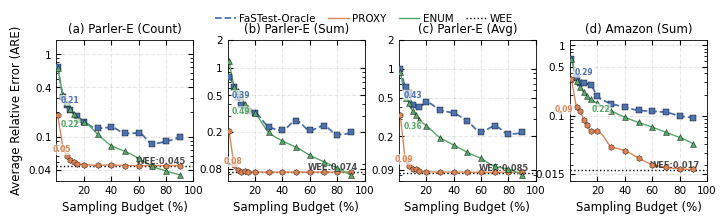

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. IEEE/ICDE 严格样式定义 (Times New Roman)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # 严格匹配 IEEE 模板
    "font.size": 8.0,                   # 图内标签字号
    "axes.labelsize": 8.5,              # 坐标轴标题
    "axes.titlesize": 8.5,              # 子图标题 (a, b, c, d)
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.6,              # 线条精细化
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.markersize": 4,              # 散点大小调整
    "legend.frameon": False,
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
# 使用更符合出版的调色盘 (如深色系，确保黑白打印可分辨)
PALETTE = sns.color_palette("deep", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FaSTest-Oracle": "s", "PROXY": "h", "ENUM": "^", "UN": "o", "PO": "d", "MAB": "v"
}

DEFAULT_OFFSETS = {
    "FaSTest-Oracle": (0, 7), "ENUM": (0, -11), "PROXY": (-6, 7),
    "UN": (6, 7), "PO": (6, -11), "MAB": (-6, -11)
}

# ==========================================
# 1. 任务配置列表
# ==========================================
CONFIGS = [
    {"title": "(a) Parler-E (Count)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "count", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0450, "ylim": (0.03, 1.5), "yticks": [0.04, 0.1, 0.4, 1.0], "wee_x": 0.95},
    {"title": "(b) Parler-E (Sum)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "sum", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0742, "ylim": (0.06, 2.0), "yticks": [0.08, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(c) Parler-E (Avg)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "avg", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0847, "ylim": (0.07, 2.0), "yticks": [0.09, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(d) Amazon (Sum)", "parent_dataset": "amazon_data", "dataset_name": "amazon_extend", "agg_type": "sum", "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability", "wee_value": 0.0171, "ylim": (0.012, 1.2), "yticks": [0.015, 0.1, 0.5, 1.0], "wee_x": 0.95, "label_offsets": {"PROXY": (-14, 8), "ENUM": (12, -12), "FaSTest-Oracle": (0, 8)}}
]

def load_and_process_data(config):
    # 此处逻辑保持不变，确保数据读取正确
    # ... (为了缩减篇幅，保持您原有的 load_and_process_data 逻辑) ...
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    json_name = f"{config['json_base']}_{agg}.json"
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path): return None
    with open(json_path, 'r') as f:
        truth_map = {str(k).replace(".graph", ""): v for k, v in json.load(f).items()}

    dfs_to_merge = []
    paths = {"FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None, 
             f"FastestO_budget_curve_{agg}.csv": "FastestO",
             f"allocation_strategy_comparison_{agg}.csv": None,
             f"Exact_structureO_budget_curve_{agg}.csv": "Exact_structureO"}

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name: df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge: return None
    df_all = pd.concat(dfs_to_merge, ignore_index=True)
    df_all["query_basename"] = df_all["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    df_all["T_true"] = df_all["query_basename"].map(truth_map)
    df_all = df_all.dropna(subset=["T_true"])
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + 1e-9)).abs()
    
    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)
    return df_all

# ==========================================
# 2. 绘制符合 IEEE 规范的图形
# ==========================================
# IEEE 双栏论文单张大图建议宽度为 7.15 英寸左右
fig, axes = plt.subplots(1, 4, figsize=(7.15, 2.2), sharey=False)

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    df_all = load_and_process_data(config)
    if df_all is None: continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]
    offsets = config.get("label_offsets", DEFAULT_OFFSETS)

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw, y_raw = subset["budget_frac"].values, subset["ARE"].values
        
        color = COLOR_MAP.get(method, 'gray')
        ls = '--' if "Oracle" in method else '-'
        lw = 1.3 if "Oracle" in method else 1.0

        # 平滑处理
        if len(x_raw) > 3:
            x_new = np.linspace(x_raw.min(), x_raw.max(), 300)
            y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
            line, = ax.plot(x_new, np.maximum(y_smooth, 0), color=color, lw=lw, ls=ls, zorder=3)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, lw=lw, ls=ls, zorder=3)

        if method not in method_added:
            global_handles.append(line)
            global_labels.append(method)
            method_added.add(method)

        # 绘制散点
        mk = MARKER_DICT.get(method, "o")
        ax.scatter(x_raw, y_raw, color=color, marker=mk, s=18, zorder=4, edgecolor='black', linewidth=0.3)

        # 10% 处的数值标注 (仅保留关键数值)
        idx_10 = np.where(np.isclose(x_raw, 0.1, atol=0.02))[0]
        if len(idx_10) > 0:
            off_x, off_y = offsets.get(method, (0, 6))
            ax.annotate(f"{y_raw[idx_10[0]]:.2f}", xy=(x_raw[idx_10[0]], y_raw[idx_10[0]]),
                        xytext=(off_x, off_y), textcoords="offset points",
                        fontsize=5.5, fontweight="bold", color=color,
                        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7, ec="none"), zorder=5)

    # 绘制 WEE 线
    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.0, zorder=1)
    if "WEE" not in method_added:
        global_handles.append(wee_line); global_labels.append("WEE"); method_added.add("WEE")
    
    # WEE 文本标注优化
    ax.text(config["wee_x"], wee_val, f"WEE:{wee_val:.3f}", color='black', fontsize=6, 
            ha='right', va='bottom', fontweight='bold', alpha=0.7)

    # 坐标轴设置
    ax.set_title(config["title"], pad=5)
    ax.set_xlabel("Sampling Budget (%)") # 严格遵循单词标注
    ax.set_xlim(0, 1.0)
    ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}"))
    
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    
    # 刻度线向内
    ax.tick_params(direction='in', which='both', top=True, right=True)
    ax.grid(True, which="major", axis="both")

# 只有最左侧显示 Y 轴名称，避免挤压
axes[0].set_ylabel("Average Relative Error (ARE)")

# 整体布局优化
plt.subplots_adjust(top=0.82, bottom=0.18, left=0.07, right=0.98, wspace=0.25)

# 图例放在顶部
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
           ncol=len(global_labels), frameon=False, columnspacing=1.2, handletextpad=0.3)

out_path = "/home/wangshuo/resource/paper_figuires/RQ2_convergence_IEEE.pdf"
plt.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ 已导出符合 IEEE 格式的图片: {out_path}")
plt.show()

✅ 图形成功保存 (修复了字体，并添加了全局 X 轴标签): /home/wangshuo/resource/paper_figuires/RQ2_convergence_IEEE.pdf


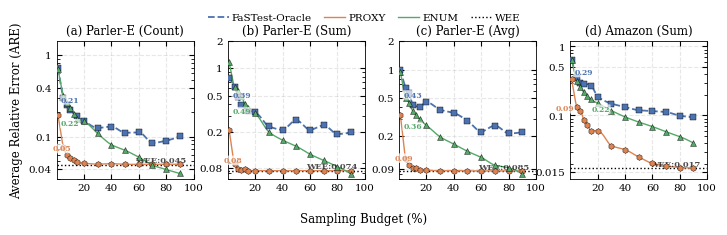

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator

# ==========================================
# 0. 修复字体问题 & 设定学术规范样式
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    # 使用通用的 serif 字体，并使用 STIX 匹配 LaTeX 风格，避免缺少 Times New Roman 的报错
    "font.family": "serif",
    # "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",  
    "font.size": 8.0,
    "axes.labelsize": 8.5,
    "axes.titlesize": 8.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.6,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.markersize": 4,
    "legend.frameon": False,
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
PALETTE = sns.color_palette("deep", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {"FaSTest-Oracle": "s", "PROXY": "h", "ENUM": "^", "UN": "o", "PO": "d", "MAB": "v"}
DEFAULT_OFFSETS = {"FaSTest-Oracle": (0, 7), "ENUM": (0, -11), "PROXY": (-6, 7), "UN": (6, 7), "PO": (6, -11), "MAB": (-6, -11)}

# ==========================================
# 1. 任务配置列表
# ==========================================
CONFIGS = [
    {"title": "(a) Parler-E (Count)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "count", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0450, "ylim": (0.03, 1.5), "yticks": [0.04, 0.1, 0.4, 1.0], "wee_x": 0.95},
    {"title": "(b) Parler-E (Sum)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "sum", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0742, "ylim": (0.06, 2.0), "yticks": [0.08, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(c) Parler-E (Avg)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "avg", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0847, "ylim": (0.07, 2.0), "yticks": [0.09, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(d) Amazon (Sum)", "parent_dataset": "amazon_data", "dataset_name": "amazon_extend", "agg_type": "sum", "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability", "wee_value": 0.0171, "ylim": (0.012, 1.2), "yticks": [0.015, 0.1, 0.5, 1.0], "wee_x": 0.95, "label_offsets": {"PROXY": (-14, 8), "ENUM": (12, -12), "FaSTest-Oracle": (0, 8)}}
]

def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    json_name = f"{config['json_base']}_{agg}.json"
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path): return None
    with open(json_path, 'r') as f:
        truth_map = {str(k).replace(".graph", ""): v for k, v in json.load(f).items()}

    dfs_to_merge = []
    paths = {"FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None, 
             f"FastestO_budget_curve_{agg}.csv": "FastestO",
             f"allocation_strategy_comparison_{agg}.csv": None,
             f"Exact_structureO_budget_curve_{agg}.csv": "Exact_structureO"}

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name: df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge: return None
    df_all = pd.concat(dfs_to_merge, ignore_index=True)
    df_all["query_basename"] = df_all["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    df_all["T_true"] = df_all["query_basename"].map(truth_map)
    df_all = df_all.dropna(subset=["T_true"])
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + 1e-9)).abs()
    
    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)
    return df_all

# ==========================================
# 2. 绘制 1x4 组合图
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(7.15, 2.3), sharey=False) # 略微增加高度以容纳全局 x 轴

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    df_all = load_and_process_data(config)
    if df_all is None: continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]
    offsets = config.get("label_offsets", DEFAULT_OFFSETS)

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw, y_raw = subset["budget_frac"].values, subset["ARE"].values
        
        color = COLOR_MAP.get(method, 'gray')
        ls = '--' if "Oracle" in method else '-'
        lw = 1.3 if "Oracle" in method else 1.0

        if len(x_raw) > 3:
            x_new = np.linspace(x_raw.min(), x_raw.max(), 300)
            y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
            line, = ax.plot(x_new, np.maximum(y_smooth, 0), color=color, lw=lw, ls=ls, zorder=3)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, lw=lw, ls=ls, zorder=3)

        if method not in method_added:
            global_handles.append(line); global_labels.append(method); method_added.add(method)

        mk = MARKER_DICT.get(method, "o")
        ax.scatter(x_raw, y_raw, color=color, marker=mk, s=18, zorder=4, edgecolor='black', linewidth=0.3)

        idx_10 = np.where(np.isclose(x_raw, 0.1, atol=0.02))[0]
        if len(idx_10) > 0:
            off_x, off_y = offsets.get(method, (0, 6))
            ax.annotate(f"{y_raw[idx_10[0]]:.2f}", xy=(x_raw[idx_10[0]], y_raw[idx_10[0]]),
                        xytext=(off_x, off_y), textcoords="offset points",
                        fontsize=5.5, fontweight="bold", color=color,
                        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7, ec="none"), zorder=5)

    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.0, zorder=1)
    if "WEE" not in method_added:
        global_handles.append(wee_line); global_labels.append("WEE"); method_added.add("WEE")
    
    ax.text(config["wee_x"], wee_val, f"WEE:{wee_val:.3f}", color='black', fontsize=6, 
            ha='right', va='bottom', fontweight='bold', alpha=0.7)

    ax.set_title(config["title"], pad=5)
    
    # 【已修改】去掉了这里子图单独的 set_xlabel
    ax.set_xlabel("") 

    ax.set_xlim(0, 1.0)
    ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}"))
    
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    
    ax.tick_params(direction='in', which='both', top=True, right=True)
    ax.grid(True, which="major", axis="both")

axes[0].set_ylabel("Average Relative Error (ARE)")

# ==========================================
# 3. 排版微调与输出
# ==========================================
# 【已修改】添加了一个全局居中的 X 轴标题，完美符合 IEEE 对横坐标的命名要求
fig.supxlabel("Sampling Budget (%)", fontsize=8.5, y=0.02)

# 将底部边距 (bottom) 稍微拉高，给全局 X 轴标题留出空间
plt.subplots_adjust(top=0.82, bottom=0.22, left=0.07, right=0.98, wspace=0.25)

fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
           ncol=len(global_labels), frameon=False, columnspacing=1.2, handletextpad=0.3)

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_convergence_IEEE.pdf")

plt.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ 图形成功保存 (修复了字体，并添加了全局 X 轴标签): {out_path}")
plt.show()

✅ 符合 ICDE (IEEE) 规范的拉伸扁平版 PDF 已成功生成: /home/wangshuo/resource/paper_figuires/RQ2_convergence_IEEE.pdf


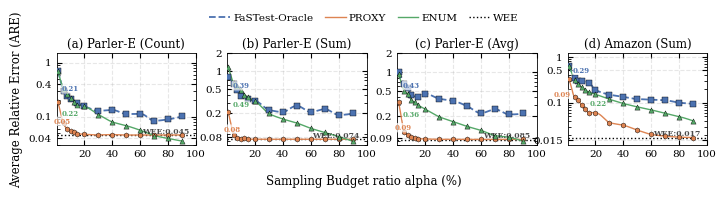

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator

# ==========================================
# 0. 设定 IEEE / ICDE 严格学术出版级样式 (启用已成功安装的 Times New Roman)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    # "font.serif": ["Times New Roman"],  # <--- 【已取消注释】严格使用标准 Times New Roman
    "mathtext.fontset": "stix",         # 公式采用 STIX，与 Times 风格高度契合
    "font.size": 8.0,
    "axes.labelsize": 8.5,
    "axes.titlesize": 8.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.6,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.markersize": 3.5,            # 略微缩小标记，使扁平图更精致
    "legend.frameon": False,
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
PALETTE = sns.color_palette("deep", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {"FaSTest-Oracle": "s", "PROXY": "h", "ENUM": "^", "UN": "o", "PO": "d", "MAB": "v"}
DEFAULT_OFFSETS = {"FaSTest-Oracle": (0, 7), "ENUM": (0, -11), "PROXY": (-6, 7), "UN": (6, 7), "PO": (6, -11), "MAB": (-6, -11)}

# ==========================================
# 1. 任务配置列表
# ==========================================
CONFIGS = [
    {"title": "(a) Parler-E (Count)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "count", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0450, "ylim": (0.03, 1.5), "yticks": [0.04, 0.1, 0.4, 1.0], "wee_x": 0.95},
    {"title": "(b) Parler-E (Sum)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "sum", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0742, "ylim": (0.06, 2.0), "yticks": [0.08, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(c) Parler-E (Avg)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "avg", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0847, "ylim": (0.07, 2.0), "yticks": [0.09, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(d) Amazon (Sum)", "parent_dataset": "amazon_data", "dataset_name": "amazon_extend", "agg_type": "sum", "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability", "wee_value": 0.0171, "ylim": (0.012, 1.2), "yticks": [0.015, 0.1, 0.5, 1.0], "wee_x": 0.95, "label_offsets": {"PROXY": (-14, 8), "ENUM": (12, -12), "FaSTest-Oracle": (0, 8)}}
]

def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    json_name = f"{config['json_base']}_{agg}.json"
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path): return None
    with open(json_path, 'r') as f:
        truth_map = {str(k).replace(".graph", ""): v for k, v in json.load(f).items()}

    dfs_to_merge = []
    paths = {"FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None, 
             f"FastestO_budget_curve_{agg}.csv": "FastestO",
             f"allocation_strategy_comparison_{agg}.csv": None,
             f"Exact_structureO_budget_curve_{agg}.csv": "Exact_structureO"}

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name: df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge: return None
    df_all = pd.concat(dfs_to_merge, ignore_index=True)
    df_all["query_basename"] = df_all["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    df_all["T_true"] = df_all["query_basename"].map(truth_map)
    df_all = df_all.dropna(subset=["T_true"])
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + 1e-9)).abs()
    
    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)
    return df_all

# ==========================================
# 2. 绘制 1x4 组合图 (高宽比重构)
# ==========================================
# 【已修改】将高度从 2.3 压缩至 1.8 英寸，实现横向拉伸、扁平美观的学术图表视觉效果
fig, axes = plt.subplots(1, 4, figsize=(7.15, 1.8), sharey=False) 

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    df_all = load_and_process_data(config)
    if df_all is None: continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]
    offsets = config.get("label_offsets", DEFAULT_OFFSETS)

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw, y_raw = subset["budget_frac"].values, subset["ARE"].values
        
        color = COLOR_MAP.get(method, 'gray')
        ls = '--' if "Oracle" in method else '-'
        lw = 1.3 if "Oracle" in method else 1.0

        if len(x_raw) > 3:
            x_new = np.linspace(x_raw.min(), x_raw.max(), 300)
            y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
            line, = ax.plot(x_new, np.maximum(y_smooth, 0), color=color, lw=lw, ls=ls, zorder=3)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, lw=lw, ls=ls, zorder=3)

        if method not in method_added:
            global_handles.append(line); global_labels.append(method); method_added.add(method)

        mk = MARKER_DICT.get(method, "o")
        ax.scatter(x_raw, y_raw, color=color, marker=mk, s=14, zorder=4, edgecolor='black', linewidth=0.3)

        # 10% 处的数据标签，文字大小降至 5.0pt 保证变扁后不显拥挤
        idx_10 = np.where(np.isclose(x_raw, 0.1, atol=0.02))[0]
        if len(idx_10) > 0:
            off_x, off_y = offsets.get(method, (0, 5))
            ax.annotate(f"{y_raw[idx_10[0]]:.2f}", xy=(x_raw[idx_10[0]], y_raw[idx_10[0]]),
                        xytext=(off_x, off_y), textcoords="offset points",
                        fontsize=5.0, fontweight="bold", color=color,
                        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7, ec="none"), zorder=5)

    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.0, zorder=1)
    if "WEE" not in method_added:
        global_handles.append(wee_line); global_labels.append("WEE"); method_added.add("WEE")
    
    # 变扁后微调 WEE 精确值标签的大小和透明度
    ax.text(config["wee_x"], wee_val, f"WEE:{wee_val:.3f}", color='black', fontsize=5.5, 
            ha='right', va='bottom', fontweight='bold', alpha=0.7)

    ax.set_title(config["title"], pad=4)
    ax.set_xlabel("") 

    ax.set_xlim(0, 1.0)
    ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}"))
    
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    
    ax.tick_params(direction='in', which='both', top=True, right=True)
    ax.grid(True, which="major", axis="both")

axes[0].set_ylabel("Average Relative Error (ARE)")

# ==========================================
# 3. 黄金比例排版微调与输出
# ==========================================
# 【已修改】因为图片变扁，全局 X 轴标题的 Y 坐标调至 0.01 避免和刻度数字重叠
fig.supxlabel("Sampling Budget ratio alpha (%)", fontsize=8.5, y=0.01)

# 【已修改】重新精调了 top 和 bottom 的比例，将 wspace（子图间距）略微缩窄，最大化画图区域
plt.subplots_adjust(top=0.76, bottom=0.25, left=0.07, right=0.98, wspace=0.22)

# 【已修改】将图例的 y 轴锚定位置 bbox_to_anchor 微调至 1.03，使其在变矮后的子图标题上方完美居中
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),
           ncol=len(global_labels), frameon=False, columnspacing=1.1, handletextpad=0.3)

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_convergence_IEEE.pdf")

plt.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ 符合 ICDE (IEEE) 规范的拉伸扁平版 PDF 已成功生成: {out_path}")
plt.show()

✅ 符合 ICDE (IEEE) 规范的拉伸扁平版 PDF 已成功生成: /home/wangshuo/resource/paper_figuires/RQ2_convergence_IEEE.pdf


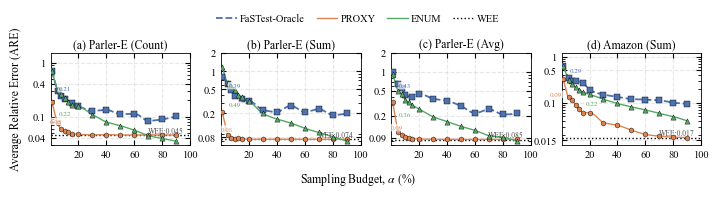

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator

# ==========================================
# 0. 设定 IEEE / ICDE 严格学术出版级样式 (启用已成功安装的 Times New Roman)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # <--- 【已取消注释】严格使用标准 Times New Roman
    "mathtext.fontset": "stix",         # 公式采用 STIX，与 Times 风格高度契合
    "font.size": 8.0,
    "axes.labelsize": 8.5,
    "axes.titlesize": 8.5,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.6,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.markersize": 3.5,            # 略微缩小标记，使扁平图更精致
    "legend.frameon": False,
})

DESIRED_ORDER = ["FaSTest-Oracle", "PROXY", "ENUM", "UN", "PO", "WEE", "MAB"]
PALETTE = sns.color_palette("deep", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {"FaSTest-Oracle": "s", "PROXY": "h", "ENUM": "^", "UN": "o", "PO": "d", "MAB": "v"}
DEFAULT_OFFSETS = {"FaSTest-Oracle": (0, 7), "ENUM": (0, -11), "PROXY": (-6, 7), "UN": (6, 7), "PO": (6, -11), "MAB": (-6, -11)}

# ==========================================
# 1. 任务配置列表
# ==========================================
CONFIGS = [
    {"title": "(a) Parler-E (Count)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "count", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0450, "ylim": (0.03, 1.5), "yticks": [0.04, 0.1, 0.4, 1.0], "wee_x": 0.95},
    {"title": "(b) Parler-E (Sum)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "sum", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0742, "ylim": (0.06, 2.0), "yticks": [0.08, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(c) Parler-E (Avg)", "parent_dataset": "parler_data", "dataset_name": "dataset_test", "agg_type": "avg", "json_base": "T_true_ML1_oracle2_probability_ML2_oracle2_probability", "wee_value": 0.0847, "ylim": (0.07, 2.0), "yticks": [0.09, 0.2, 0.5, 1.0, 2.0], "wee_x": 0.95},
    {"title": "(d) Amazon (Sum)", "parent_dataset": "amazon_data", "dataset_name": "amazon_extend", "agg_type": "sum", "json_base": "T_true_ML3_oracle2_probability_ML2_oracle1_probability", "wee_value": 0.0171, "ylim": (0.012, 1.2), "yticks": [0.015, 0.1, 0.5, 1.0], "wee_x": 0.95, "label_offsets": {"PROXY": (-14, 8), "ENUM": (12, -12), "FaSTest-Oracle": (0, 8)}}
]

def load_and_process_data(config):
    parent = config["parent_dataset"]
    dataset = config["dataset_name"]
    agg = config["agg_type"]
    base_dir = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/efficiency"
    json_name = f"{config['json_base']}_{agg}.json"
    json_path = f"/home/wangshuo/resource/datasets/{parent}/{dataset}/results/{json_name}"
    
    if not os.path.exists(json_path): return None
    with open(json_path, 'r') as f:
        truth_map = {str(k).replace(".graph", ""): v for k, v in json.load(f).items()}

    dfs_to_merge = []
    paths = {"FOIS_rs_FOSS_nrs_budget_curve_fast.csv": None, 
             f"FastestO_budget_curve_{agg}.csv": "FastestO",
             f"allocation_strategy_comparison_{agg}.csv": None,
             f"Exact_structureO_budget_curve_{agg}.csv": "Exact_structureO"}

    for file_name, method_name in paths.items():
        p = os.path.join(base_dir, file_name)
        if os.path.exists(p):
            df = pd.read_csv(p)
            if method_name: df["method"] = method_name
            dfs_to_merge.append(df)

    if not dfs_to_merge: return None
    df_all = pd.concat(dfs_to_merge, ignore_index=True)
    df_all["query_basename"] = df_all["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    df_all["T_true"] = df_all["query_basename"].map(truth_map)
    df_all = df_all.dropna(subset=["T_true"])
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + 1e-9)).abs()
    
    rename_dict = {"Exact_structureO": "ENUM", "FastestO": "FaSTest-Oracle", "8_POSSA": "PROXY"}
    df_all["method"] = df_all["method"].replace(rename_dict)
    return df_all

# ==========================================
# 2. 绘制 1x4 组合图 (高宽比重构)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(7.15, 1.8), sharey=False) 

global_handles, global_labels = [], []
method_added = set()

for idx, config in enumerate(CONFIGS):
    ax = axes[idx]
    df_all = load_and_process_data(config)
    if df_all is None: continue

    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]
    offsets = config.get("label_offsets", DEFAULT_OFFSETS)

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw, y_raw = subset["budget_frac"].values, subset["ARE"].values
        
        color = COLOR_MAP.get(method, 'gray')
        ls = '--' if "Oracle" in method else '-'
        lw = 1.3 if "Oracle" in method else 1.0

        if len(x_raw) > 3:
            x_new = np.linspace(x_raw.min(), x_raw.max(), 300)
            y_smooth = PchipInterpolator(x_raw, y_raw)(x_new)
            line, = ax.plot(x_new, np.maximum(y_smooth, 0), color=color, lw=lw, ls=ls, zorder=3)
        else:
            line, = ax.plot(x_raw, y_raw, color=color, lw=lw, ls=ls, zorder=3)

        if method not in method_added:
            global_handles.append(line); global_labels.append(method); method_added.add(method)

        mk = MARKER_DICT.get(method, "o")
        ax.scatter(x_raw, y_raw, color=color, marker=mk, s=14, zorder=4, edgecolor='black', linewidth=0.3)

        idx_10 = np.where(np.isclose(x_raw, 0.1, atol=0.02))[0]
        if len(idx_10) > 0:
            off_x, off_y = offsets.get(method, (0, 5))
            # 🚨 【已修改】移除了这里的 fontweight='bold'
            ax.annotate(f"{y_raw[idx_10[0]]:.2f}", xy=(x_raw[idx_10[0]], y_raw[idx_10[0]]),
                        xytext=(off_x, off_y), textcoords="offset points",
                        fontsize=5.0, color=color,
                        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7, ec="none"), zorder=5)

    wee_val = config["wee_value"]
    wee_line = ax.axhline(y=wee_val, color='black', linestyle=':', linewidth=1.0, zorder=1)
    if "WEE" not in method_added:
        global_handles.append(wee_line); global_labels.append("WEE"); method_added.add("WEE")
    
    # 🚨 【已修改】移除了这里的 fontweight='bold'
    ax.text(config["wee_x"], wee_val, f"WEE:{wee_val:.3f}", color='black', fontsize=5.5, 
            ha='right', va='bottom', alpha=0.7)

    ax.set_title(config["title"], pad=4)
    ax.set_xlabel("") 

    ax.set_xlim(0, 1.0)
    ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x*100)}"))
    
    ax.set_yscale("log")
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    
    ax.tick_params(direction='in', which='both', top=True, right=True)
    ax.grid(True, which="major", axis="both")

axes[0].set_ylabel("Average Relative Error (ARE)")

# ==========================================
# 3. 黄金比例排版微调与输出
# ==========================================
# 🚨 【已修改】根据 IEEE 要求，使用逗号引出符号并用括号包围单位
fig.supxlabel(r"Sampling Budget, $\alpha$ (%)", fontsize=8.5, y=0.01)

plt.subplots_adjust(top=0.76, bottom=0.25, left=0.07, right=0.98, wspace=0.22)

fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),
           ncol=len(global_labels), frameon=False, columnspacing=1.1, handletextpad=0.3)

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "RQ2_convergence_IEEE.pdf")

plt.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ 符合 ICDE (IEEE) 规范的拉伸扁平版 PDF 已成功生成: {out_path}")
plt.show()

##### 4.12 [重要]: 绘制多推理谓词每个查询的误差组成误差曲线:

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 配置路径
# ==========================================
# dataset_name = "dataset_three"
parent_dataset='amazon_data'
dataset_name = "amazon_extend"
# parent_dataset='parler_data'
# dataset_name = "dataset_test"
json_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/T_true_ML3_oracle2_probability_ML2_oracle1_probability_avg.json"
csv_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/efficiency/allocation_strategy_comparison_avg.csv"
# csv_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/efficiency/Exact_structureO_budget_curve_avg.csv"
# csv_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/efficiency/FastestO_budget_curve_count.csv"

# ==========================================
# 2. 数据加载与预处理
# ==========================================
print("正在加载数据...")
# 加载 T_true
with open(json_path, 'r') as f:
    t_true_dict = json.load(f)

# 加载估计结果 CSV
df_hat = pd.read_csv(csv_path)

# 确保 T_true 字典中的值是浮点数，并映射到 DataFrame
# 使用 map 前确保 query_basename 是字符串
df_hat['T_true_actual'] = df_hat['query_basename'].astype(str).map(t_true_dict)

# 过滤掉 JSON 中不存在的查询 (避免 NaN)
df_hat = df_hat.dropna(subset=['T_true_actual'])

# 计算绝对误差率: |T_hat - T_true| / T_true
# 注意：如果 T_true 为 0，误差率设为 0
df_hat['abs_error_rate'] = np.where(
    df_hat['T_true_actual'] > 0,
    abs(df_hat['T_hat'] - df_hat['T_true_actual']) / df_hat['T_true_actual'],
    0
)

# ==========================================
# 3. 误差分析与绘图
# ==========================================
# 获取所有不同的采样预算
budgets = sorted(df_hat['budget_frac'].unique())

for budget in budgets:
    # 提取当前采样率下的数据
    df_budget = df_hat[df_hat['budget_frac'] == budget].copy()
    
    # 针对每个查询聚合多个 run_id 的平均误差率
    df_grouped = df_budget.groupby('query_basename')['abs_error_rate'].mean().reset_index()
    
    # 按误差率从大到小排序
    df_sorted = df_grouped.sort_values(by='abs_error_rate', ascending=False).reset_index(drop=True)
    
    # --- 打印误差最高的前 20 个查询 ---
    print(f"\n" + "="*60)
    print(f">>> 采样预算 Budget Frac: {budget}")
    print(f"误差最高的前 20 个查询:")
    print("-" * 60)
    # 格式化打印：左对齐查询名，右对齐百分比误差
    for i, row in df_sorted.head(113).iterrows():
        print(f"{i+1:2d}. {row['query_basename']:<40} | Error Rate: {row['abs_error_rate']:.2%}")
    print("="*60)
    
    # --- 绘制折线图 ---
    plt.figure(figsize=(12, 6))
    
    # 使用索引作为横坐标 (0, 1, 2...)
    plt.plot(df_sorted.index, df_sorted['abs_error_rate'], 
             marker='o', linestyle='-', markersize=4, color='crimson', label=f'Avg Error (Budget {budget})')
    
    # 填充阴影区域
    plt.fill_between(df_sorted.index, df_sorted['abs_error_rate'], color='crimson', alpha=0.1)
    
    # 设置图表属性
    plt.title(f"Query Error Rate Distribution (Budget Frac: {budget})\n(Sorted from High to Low)", fontsize=14)
    plt.xlabel("Query Rank (Index 0 is Highest Error)", fontsize=12)
    plt.ylabel("Absolute Error Rate (|T_hat - T_true| / T_true)", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    
    # 如果误差率极大，可以考虑开启对数坐标轴，若不需要请注释掉下面一行
    # plt.yscale('log') 
    
    # 直接显示图像
    plt.tight_layout()
    plt.show()

print("\n所有预算下的分析绘图已完成。")

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 配置路径
# ==========================================
parent_dataset = 'amazon_data'
dataset_name = "amazon_extend"
json_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/T_true_ML3_oracle2_probability_ML2_oracle1_probability_count.json"
csv_path = f"/home/wangshuo/resource/datasets/{parent_dataset}/{dataset_name}/results/efficiency/allocation_strategy_comparison_ablation_count.csv"

# ==========================================
# 2. 数据加载与预处理
# ==========================================
print("正在加载数据...")

with open(json_path, 'r') as f:
    t_true_dict = json.load(f)

df_hat = pd.read_csv(csv_path)
df_hat.columns = df_hat.columns.str.strip()

if "method" not in df_hat.columns:
    raise ValueError(f"CSV 中找不到 method 列，当前列名为: {df_hat.columns.tolist()}")

# 只保留 method = 8_POSSA
df_hat = df_hat[df_hat["method"] == "8_POSSA"].copy()

if df_hat.empty:
    raise ValueError("过滤后没有找到 method = '8_POSSA' 的数据。")

df_hat["T_true_actual"] = df_hat["query_basename"].astype(str).map(t_true_dict)
df_hat = df_hat.dropna(subset=["T_true_actual"])

df_hat["abs_error_rate"] = np.where(
    df_hat["T_true_actual"] > 0,
    abs(df_hat["T_hat"] - df_hat["T_true_actual"]) / df_hat["T_true_actual"],
    0
)

# ==========================================
# 3. 误差分析与绘图
# ==========================================
budgets = sorted(df_hat["budget_frac"].unique())

for budget in budgets:
    df_budget = df_hat[df_hat["budget_frac"] == budget].copy()

    df_grouped = df_budget.groupby("query_basename")["abs_error_rate"].mean().reset_index()
    df_sorted = df_grouped.sort_values(by="abs_error_rate", ascending=False).reset_index(drop=True)

    print(f"\n" + "=" * 60)
    print(f">>> 采样预算 Budget Frac: {budget}")
    print(f"method = 8_POSSA，误差最高的前 20 个查询:")
    print("-" * 60)

    for i, row in df_sorted.head(20).iterrows():
        print(f"{i+1:2d}. {row['query_basename']:<40} | Error Rate: {row['abs_error_rate']:.2%}")

    print("=" * 60)

    plt.figure(figsize=(12, 6))
    plt.plot(
        df_sorted.index,
        df_sorted["abs_error_rate"],
        marker="o",
        linestyle="-",
        markersize=4,
        color="crimson",
        label=f"8_POSSA Avg Error (Budget {budget})"
    )
    plt.fill_between(df_sorted.index, df_sorted["abs_error_rate"], color="crimson", alpha=0.1)

    plt.title(f"8_POSSA Query Error Rate Distribution (Budget Frac: {budget})\n(Sorted from High to Low)", fontsize=14)
    plt.xlabel("Query Rank (Index 0 is Highest Error)", fontsize=12)
    plt.ylabel("Absolute Error Rate (|T_hat - T_true| / T_true)", fontsize=12)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n所有预算下的 8_POSSA 分析绘图已完成。")

##### x. 画出allocation_strategy_comparison_ablation_sum.csv 内文件中各个method方法的CDF图,AAE度量,

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os

# ================= 1. 配置文件路径 =================
csv_path = '/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results/efficiency/allocation_strategy_comparison_ablation_sum.csv'
json_path = '/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results/T_true_ML3_oracle1_probability_ML2_oracle1_probability_sum.json'

# ================= 2. 读取数据并映射 T_true =================
# 读取 CSV
df = pd.read_csv(csv_path)

# 读取 JSON 中的 T_true
with open(json_path, 'r', encoding='utf-8') as f:
    t_true_dict = json.load(f)

# 将 JSON 中的 T_true 映射到 DataFrame 中
df['T_true_real'] = df['query_basename'].map(t_true_dict)

# 检查是否有匹配失败的情况（如果有，打印警告）
missing_t_true = df['T_true_real'].isnull().sum()
if missing_t_true > 0:
    print(f"警告: 有 {missing_t_true} 行数据未能在 JSON 中找到对应的 T_true！")
    df = df.dropna(subset=['T_true_real'])

# ================= 3. 重新计算 AAE =================
# 核心修改：如果 T_true_real == 0，则 AAE 直接为 0；否则按公式计算
df['AAE'] = np.where(
    df['T_true_real'] == 0, 
    0.0, 
    abs(df['T_true_real'] - df['T_hat']) / df['T_true_real']
)

# ================= 4. 统计不同方法的均值和中位数 =================
stats = df.groupby(['budget_frac', 'method'])['AAE'].agg(
    Mean='mean', 
    Median='median'
).reset_index()

print("========== 基于 JSON T_true 重新计算的 AAE 均值与中位数 ==========")
print(stats.to_string(index=False))
print("==================================================================\n")

# ================= 5. 绘制并保存 CDF 图 =================
# 获取所有独特的采样率 (budget_frac)
budget_fracs = sorted(df['budget_frac'].unique())

# 设置更美观的绘图风格
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

for frac in budget_fracs:
    plt.figure(figsize=(8, 6), dpi=150)
    
    # 获取当前采样率的数据
    subset = df[df['budget_frac'] == frac]
    
    # 绘制 CDF 曲线
    ax = sns.ecdfplot(
        data=subset, 
        x='AAE', 
        hue='method', 
        linewidth=2.5,
        palette="tab10"  # tab10 颜色对比鲜明
    )
    
    plt.title(f'CDF of AAE at Sampling Rate (budget_frac = {frac})', fontsize=14, fontweight='bold')
    plt.xlabel('AAE (Absolute Relative Error)', fontsize=12)
    plt.ylabel('Cumulative Probability (CDF)', fontsize=12)
    
    # 将图例移到图像右侧外部，防止遮挡曲线
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.05, 1), title='Method')
    
    plt.tight_layout()
    
    # 保存并显示图片
    plt.show()
    save_filename = f'/home/wangshuo/resource/datasets/parler_data/dataset_test/results/efficiency/CDF_AAE_frac_{frac}.png'
    # plt.savefig(save_filename, bbox_inches='tight')
    print(f"已生成并保存图表: {save_filename}")
    
    plt.close() # 关闭图窗，避免在内存中不断堆叠

FASTEST-ORACLE, ENUM , PROXY RE分布曲线

[*] 读取数据: 数据集=amazon_extend, 指标=avg, 误差计算=ARE
[+] 成功加载 Ground Truth JSON，包含 179 个有效查询记录。
[+] 成功生成 CDF图 (avg): /home/wangshuo/resource/paper_figuires/cdf_parler_post_budget_10_avg.pdf


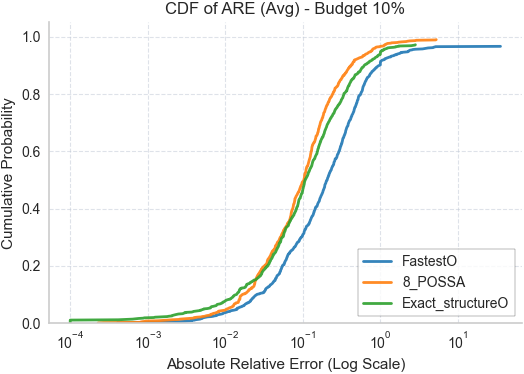

  AVG - ARE Metrics [Budget = 10%]
                   Mean  Median    P90     P95      Max
method                                                 
FastestO         39.35%  19.32% 74.23% 105.68% 3544.82%
8_POSSA          19.04%  10.09% 39.25%  66.64%  525.95%
Exact_structureO 21.08%  10.47% 52.24%  83.29%  283.27%



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json  # [新增] 导入 json 模块

# ==========================================
# 0. VLDB 期刊级全局绘图配置 (Strict Publisher Standards)
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 1.2,      
    'grid.linestyle': '--',
    'grid.alpha': 0.5
})

# ==========================================
# 1. 核心控制参数
# ==========================================
parent_data = 'amazon_data'
dataset_name = 'amazon_extend'
# parent_data = 'parler_data'
# dataset_name = 'dataset_test'
AGG_TYPE = 'avg'  
main_dataset = 'parler'
main_predicate_obj = 'post'

# [修正]：将原先未定义的 parent_dataset 修改为 parent_data
base_dir = f"/home/wangshuo/resource/datasets/{parent_data}/{dataset_name}/results/efficiency"

# 文件路径
path_fast = os.path.join(base_dir, f"FastestO_budget_curve_{AGG_TYPE}.csv")
path_alloc = os.path.join(base_dir, f"allocation_strategy_comparison_{AGG_TYPE}.csv")
path_exact = os.path.join(base_dir, f"Exact_structureO_budget_curve_{AGG_TYPE}.csv")

# [新增] Ground Truth 文件路径
path_gt = os.path.join(f'/home/wangshuo/resource/datasets/{parent_data}/{dataset_name}/results', f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{AGG_TYPE}.json")
# path_gt = os.path.join(f'/home/wangshuo/resource/datasets/{parent_data}/{dataset_name}/results', f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{AGG_TYPE}.json")

out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)

PLOTTING_BUDGETS = [0.1] 

ERROR_METRIC = 'ARE'      
X_AXIS_SCALE = 'log'      
X_LIMIT_LINEAR = 0.5      

# ==========================================
# 2. 数据加载与对齐 (含 Ground Truth 映射)
# ==========================================
print(f"[*] 读取数据: 数据集={dataset_name}, 指标={AGG_TYPE}, 误差计算={ERROR_METRIC}")

# 2.1 [新增] 读取 Ground Truth JSON
truth_map = {}
if os.path.exists(path_gt):
    with open(path_gt, 'r') as f:
        raw_truth_map = json.load(f)
    # [关键优化]：过滤掉值为 None (除零错误占位符) 的键值对，保证 float 正常转换
    truth_map = {str(k).replace('.graph', ''): float(v) for k, v in raw_truth_map.items() if v is not None}
    print(f"[+] 成功加载 Ground Truth JSON，包含 {len(truth_map)} 个有效查询记录。")
else:
    raise FileNotFoundError(f"[Error] 找不到 Ground Truth 文件，请检查路径: {path_gt}")

dfs = []

# 2.2 加载 FastestO
if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast["method"] = "FastestO"
    dfs.append(df_fast)

# 2.3 加载 8_POSSA
if os.path.exists(path_alloc):
    df_alloc = pd.read_csv(path_alloc)
    dfs.append(df_alloc)

# 2.4 加载 Exact_structureO
if os.path.exists(path_exact):
    df_exact = pd.read_csv(path_exact)
    if "method" not in df_exact.columns:
        df_exact["method"] = "Exact_structureO"
    dfs.append(df_exact)
else:
    print(f"[Warn] Exact_structureO 文件缺失: {path_exact}")

# 2.5 合并数据与 GT 映射
df_final_list = []
target_cols = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

for df in dfs:
    temp = df.copy()
    if "query_basename" in temp.columns:
        # 清洗 CSV 中的查询名
        temp["query_basename"] = temp["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    
    # [新增] 强制从 truth_map 映射真实的 T_true
    if "query_basename" in temp.columns:
        temp["T_true"] = temp["query_basename"].map(truth_map)
        # 丢弃那些在 JSON 中找不到 Ground Truth（或之前为 None）的数据行
        temp = temp.dropna(subset=["T_true"])
        
    if set(target_cols).issubset(temp.columns):
        df_final_list.append(temp[target_cols])

if not df_final_list:
    raise ValueError("没有合并到任何有效数据，请检查 CSV 文件列名或 Ground Truth 匹配是否成功！")

df_all = pd.concat(df_final_list, ignore_index=True)

# ==========================================
# 3. 动态误差计算与坐标映射
# ==========================================
df_all = df_all[df_all["T_true"] != 0].copy()
epsilon = 1e-9 

df_all["ARE"] = (df_all["T_hat"] - df_all["T_true"]).abs() / (df_all["T_true"] + epsilon)
df_all["SymRE"] = (df_all["T_hat"] - df_all["T_true"]).abs() / (0.5 * (df_all["T_hat"] + df_all["T_true"]) + epsilon)

error_col = ERROR_METRIC
base_x_label = "Absolute Relative Error" if ERROR_METRIC == 'ARE' else "Symmetric Relative Error (Abs)"

if X_AXIS_SCALE == 'log':
    df_all['PlotValue'] = np.maximum(df_all[error_col], 1e-4)
    x_label = f"{base_x_label} (Log Scale)"
else:
    df_all['PlotValue'] = df_all[error_col]
    x_label = f"{base_x_label} (Linear Scale)"

# ==========================================
# 4. 绘图配色配置 
# ==========================================
desired_order = [
    "FastestO",
    "8_POSSA",
    "Exact_structureO" 
]
available_methods = [m for m in desired_order if m in df_all["method"].unique()]

palette = sns.color_palette("tab10", n_colors=len(available_methods)) 
color_map = dict(zip(available_methods, palette))

# ==========================================
# 5. 循环绘制 CDF 
# ==========================================
for budget in PLOTTING_BUDGETS:
    mask = df_all["budget_frac"].apply(lambda x: np.isclose(x, budget, atol=1e-4))
    subset = df_all[mask].copy()
    
    if subset.empty or subset.dropna(subset=[error_col]).empty:
        print(f"[Warn] Budget {budget} 没有有效数据，跳过绘制。")
        continue

    current_methods = [m for m in available_methods if m in subset["method"].unique()]
    if not current_methods:
        continue

    fig, ax = plt.subplots(figsize=(5.5, 4))

    for method in current_methods:
        subset_m = subset[subset['method'] == method]['PlotValue'].sort_values()
        if subset_m.empty: continue
        
        y_vals = np.arange(1, len(subset_m) + 1) / len(subset_m)
        
        ax.plot(subset_m, y_vals, label=method, color=color_map[method], 
                 linewidth=2.0, linestyle='-', alpha=0.9)

    ax.set_title(f"CDF of {ERROR_METRIC} ({AGG_TYPE.capitalize()}) - Budget {int(budget*100)}%")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Cumulative Probability")
    
    ax.legend(loc='lower right', frameon=True, edgecolor='black', fancybox=False)
    ax.grid(True, which="major")
    
    ax.set_ylim(0, 1.05)
    if X_AXIS_SCALE == 'log':
        ax.set_xscale('log')
    elif X_LIMIT_LINEAR:
        ax.set_xlim(0, X_LIMIT_LINEAR)

    
    fig.tight_layout()
    
    out_pdf_path = os.path.join(out_dir, f"cdf_{main_dataset}_{main_predicate_obj}_budget_{int(budget*100)}_{AGG_TYPE}.pdf")
    fig.savefig(out_pdf_path, format='pdf', bbox_inches='tight', dpi=300)
    print(f"[+] 成功生成 CDF图 ({AGG_TYPE}): {out_pdf_path}")
    plt.show()
    plt.close(fig)
    
    # --- 终端统计表 ---
    percentiles = [0.9, 0.95]
    agg_funcs = {'Mean': 'mean', 'Median': 'median', 'Max': 'max'}
    for p in percentiles:
        agg_funcs[f"P{int(p*100)}"] = lambda x, q=p: x.quantile(q)

    summary_table = subset.groupby('method')[error_col].agg(**agg_funcs)
    existing_order = [m for m in current_methods if m in summary_table.index]
    summary_table = summary_table.loc[existing_order]
    col_order = ['Mean', 'Median'] + [f"P{int(p*100)}" for p in percentiles] + ['Max']
    
    summary_table_percent = summary_table[col_order] * 100

    print("="*85)
    print(f"  {AGG_TYPE.upper()} - {ERROR_METRIC} Metrics [Budget = {int(budget*100)}%]")
    print("="*85)
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.2f}%'.format):
        print(summary_table_percent)
    print("="*85 + "\n")